# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 1   |  |
| :-------------|:-------------|
|Meike Ligtenberg| 6242545 |
| Pepper van Berkum| 6525512 |
| Ebe Polman| 6581455 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Meike', 'Pepper','Ebe']

## Opdracht 1: Planning.

| Planning Groep: 1     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie af| 11.30 |
| Testen meetopstelling | 12.00 |
| Algoritme bedenken| 13.45 |
|Iteratie 0 | 14.30 | 
| Iteraties | 16.30 |
| Algoritme aan TA laten zien| 16.30|
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12.30 - 13.30 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

Wij zijn vergeten om een foto te maken van de kalibratie-opstelling.

kalibratie-opstelling groep [nummer]
<img src="tudelftLogo.png" width="400">

[0.03435336 0.14967466]


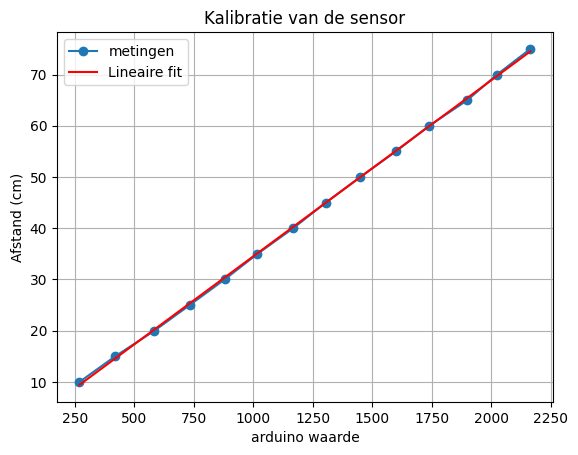

In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

afstanden = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75])
arduino_waarden = np.array([270, 420, 585, 733, 880, 1018, 1168, 1305, 1450, 1600, 1740, 1900, 2025, 2165])

def lineair(x, a, b):
    return a * x + b

a, b = curve_fit(lineair, arduino_waarden, afstanden)

print(a)

plt.figure()
plt.plot(arduino_waarden, afstanden, label = 'metingen', marker='o')
plt.plot(arduino_waarden, lineair(arduino_waarden, a[0], a[1]), label='Lineaire fit', color='red')
plt.xlabel('arduino waarde')
plt.ylabel('Afstand (cm)')
plt.title('Kalibratie van de sensor')
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  41
1   0  30   0  20  40
2  40   0  30   0  41
3  30   0  20   0  41


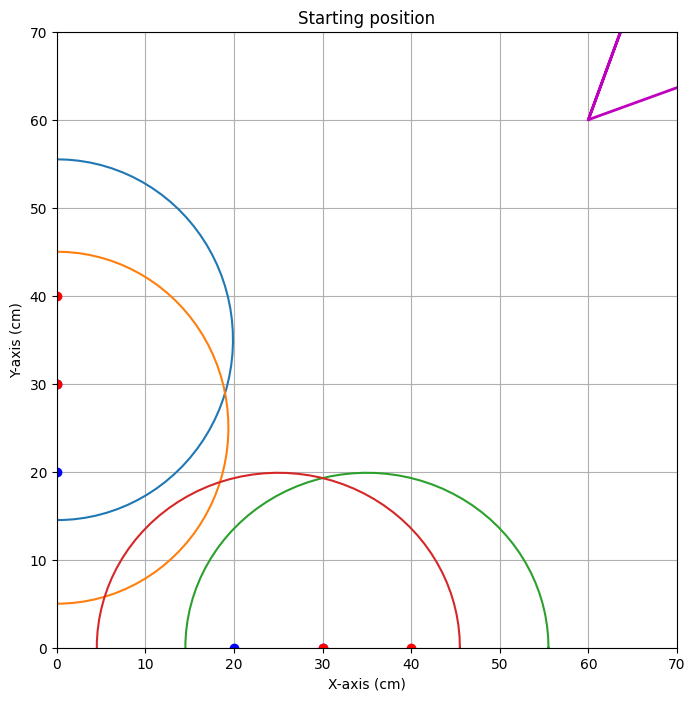


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.205


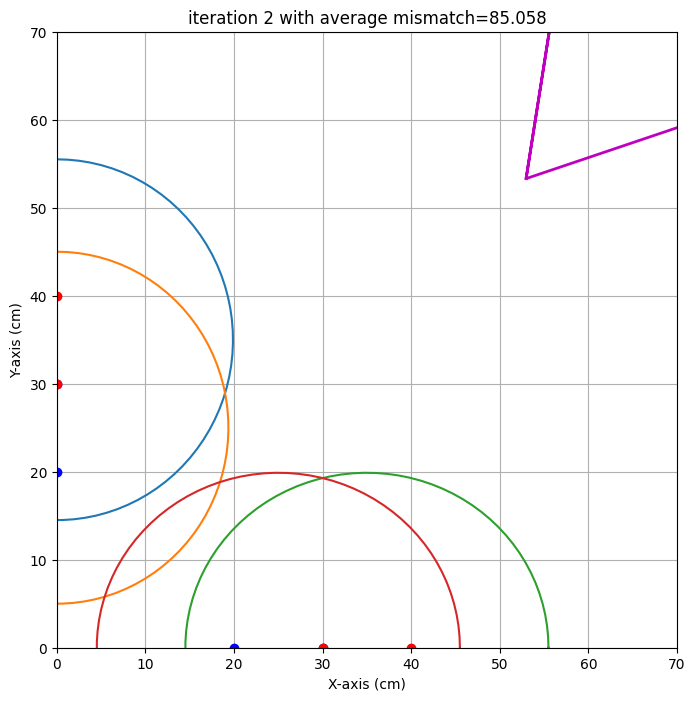

end iteration 2 with average mismatch=85.058


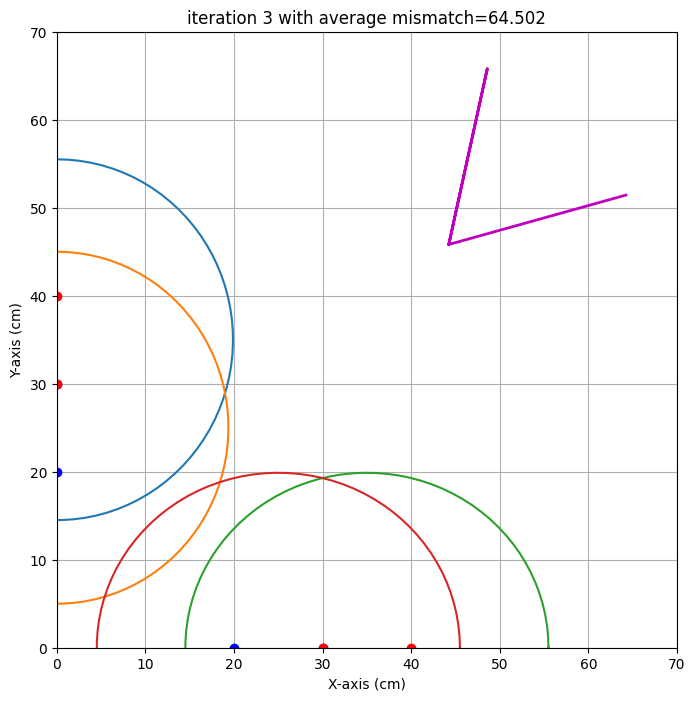

end iteration 3 with average mismatch=64.502


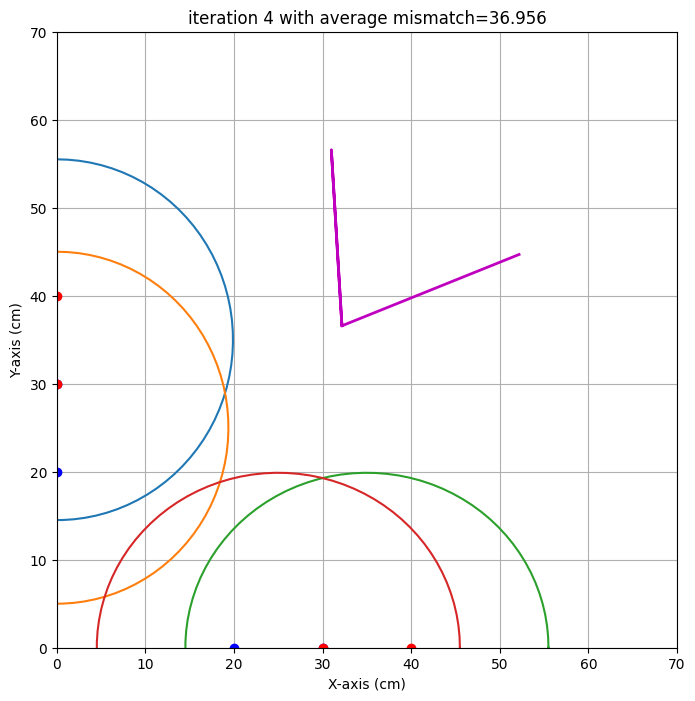

end iteration 4 with average mismatch=36.956


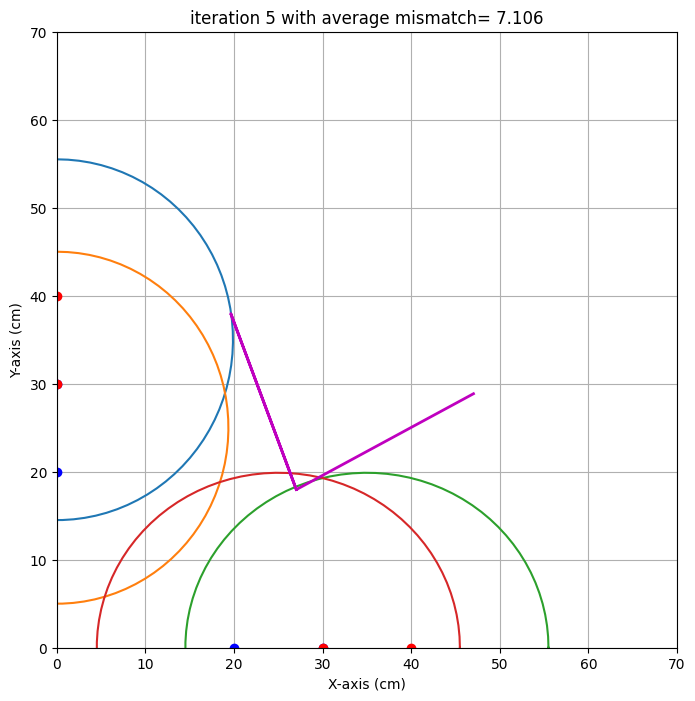

end iteration 5 with average mismatch= 7.106


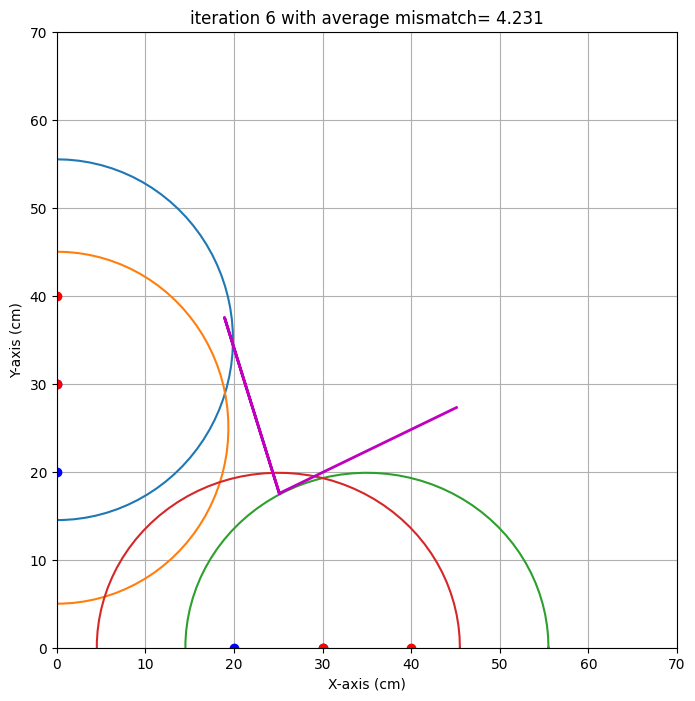

end iteration 6 with average mismatch= 4.231


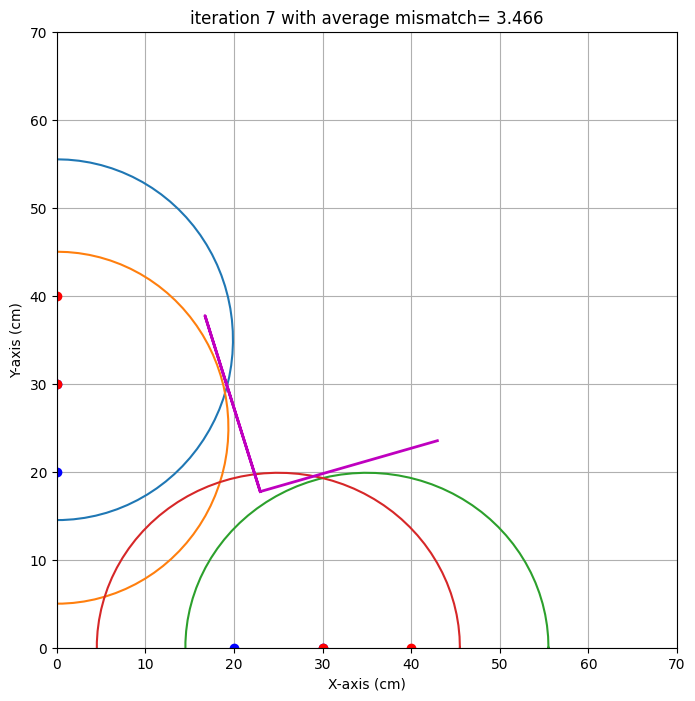

end iteration 7 with average mismatch= 3.466
end iteration 8 with average mismatch= 3.212


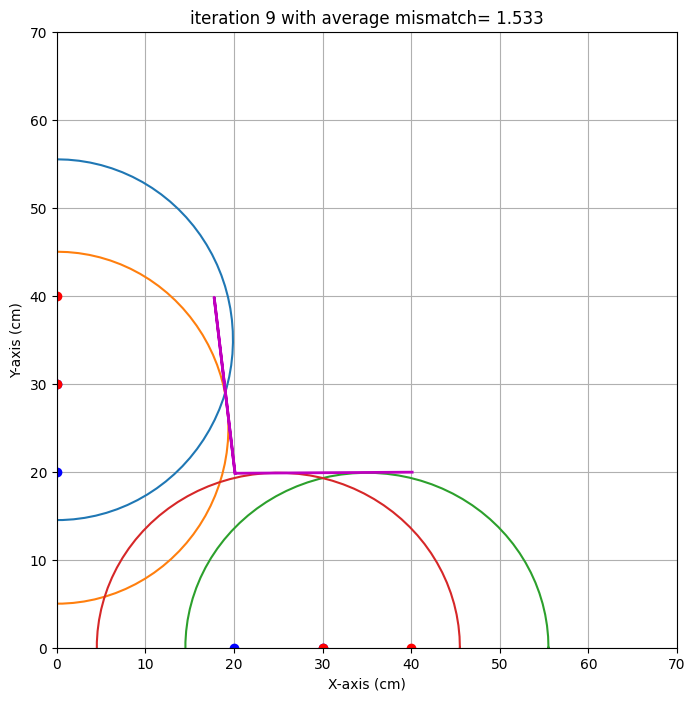

end iteration 9 with average mismatch= 1.533


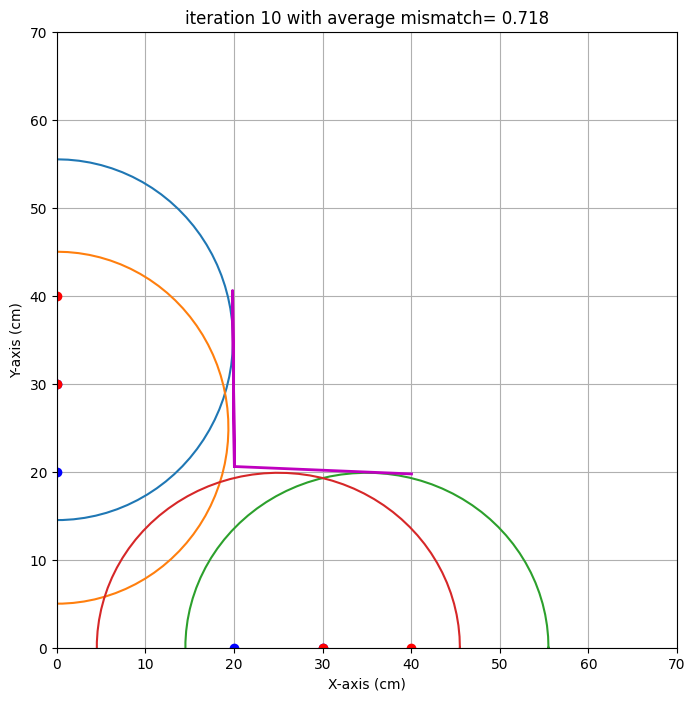

end iteration 10 with average mismatch= 0.718
end iteration 11 with average mismatch= 0.698


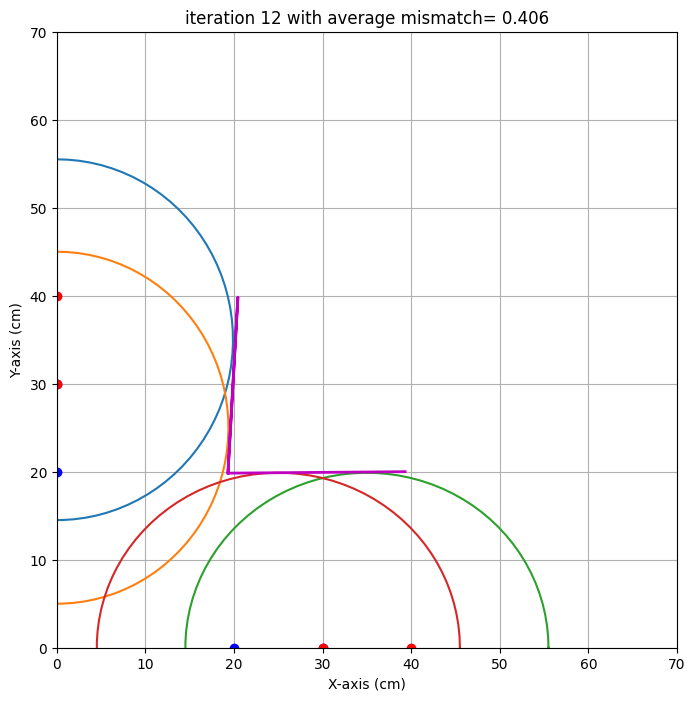

end iteration 12 with average mismatch= 0.406
end iteration 13 with average mismatch= 0.386


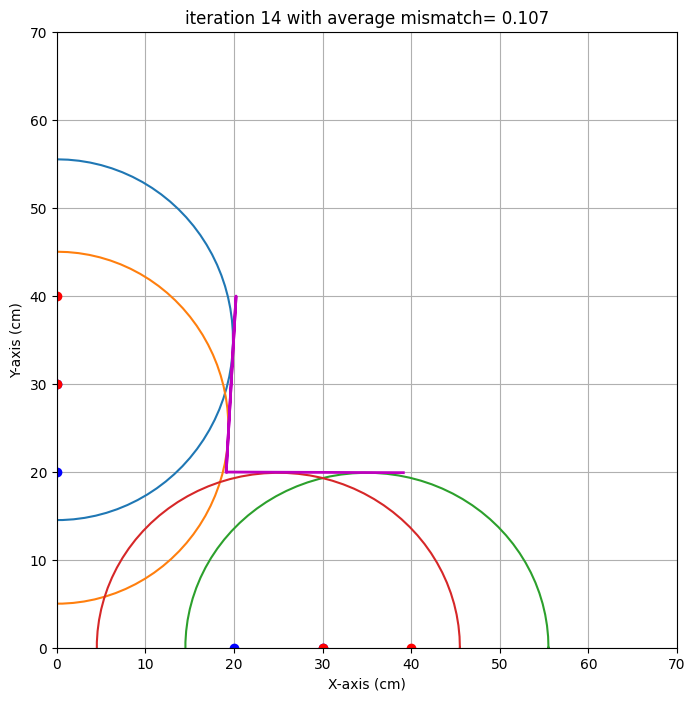

end iteration 14 with average mismatch= 0.107


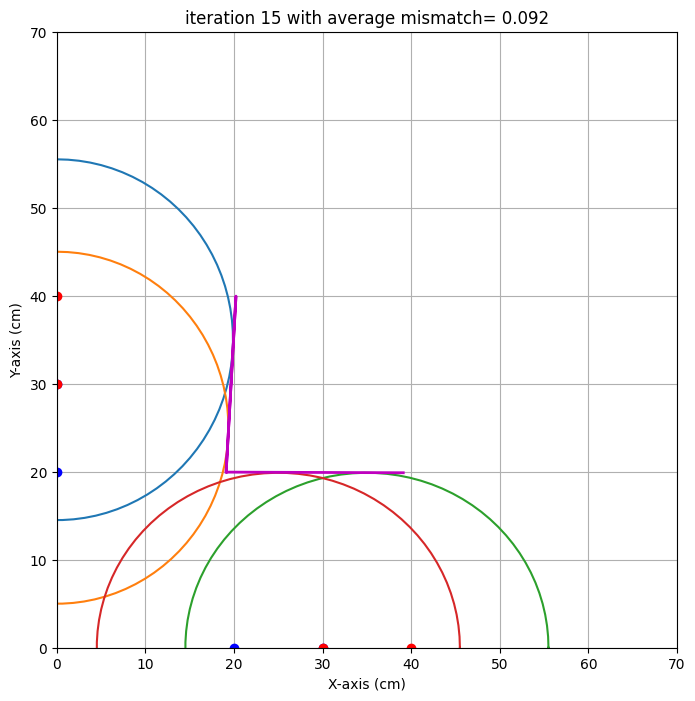

end iteration 15 with average mismatch= 0.092
end iteration 16 with average mismatch= 0.092
end iteration 17 with average mismatch= 0.092
end iteration 18 with average mismatch= 0.092
end iteration 19 with average mismatch= 0.092
end iteration 20 with average mismatch= 0.092
end iteration 21 with average mismatch= 0.092
end iteration 22 with average mismatch= 0.092
end iteration 23 with average mismatch= 0.092
end iteration 24 with average mismatch= 0.092
end iteration 25 with average mismatch= 0.092
end iteration 26 with average mismatch= 0.092
end iteration 27 with average mismatch= 0.092
end iteration 28 with average mismatch= 0.092
end iteration 29 with average mismatch= 0.092
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.092
###############################################################################
end of iteration  30
Best

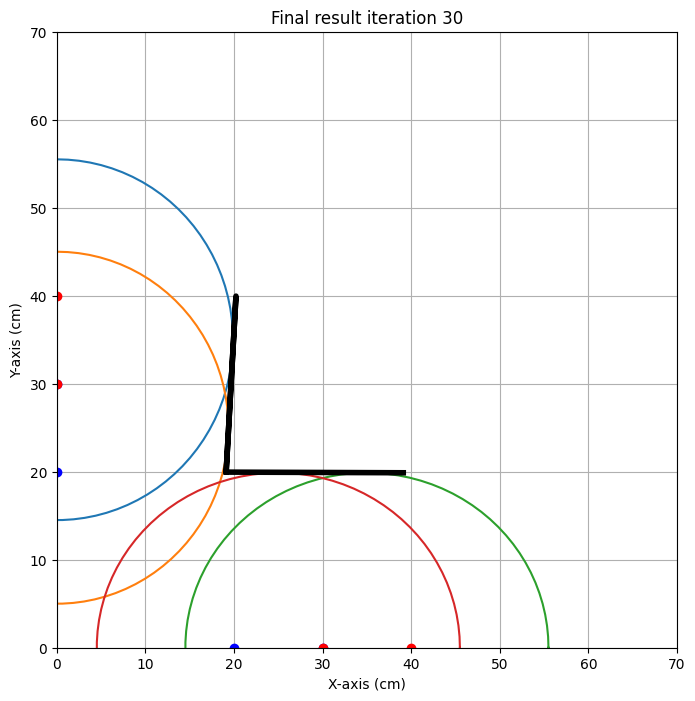

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41],
    [0,30,0,20,40],
    #[0,10,0,20,160],
    [40,0,30,0,41],
    [30,0,20,0,41],
    #[10,0,20,0,170],
    #[10,0,0,10,160]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.1 cm met een standaardafwijking van 0.0 cm 
y0: 20.0 cm met een standaardafwijking van 0.0 cm 
alpha: -0.2 graden met een standaardafwijking van 0.0 graad 
beta: 3.2 graden met een standaardafwijking van 0.0 graad 



Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  45   0  30   83
1  10   0   0  10  104
2   0  65   0  70   90


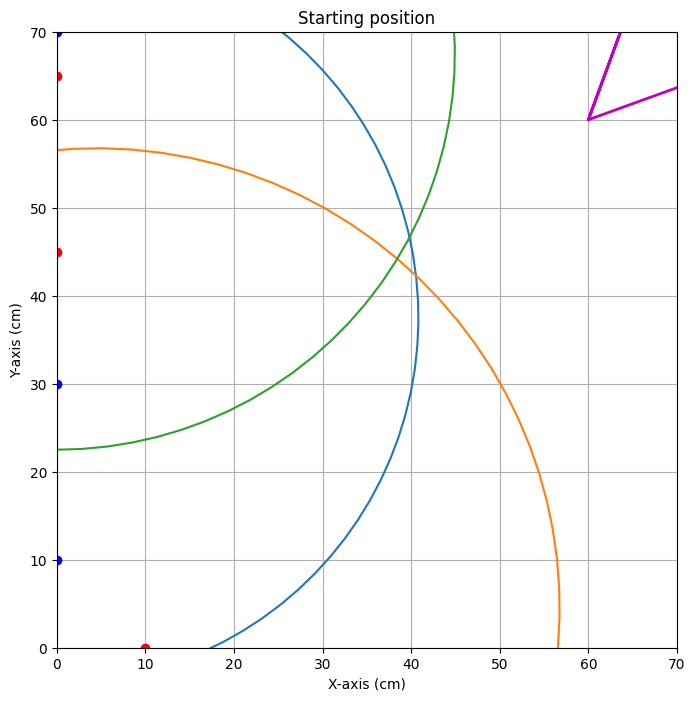


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.010


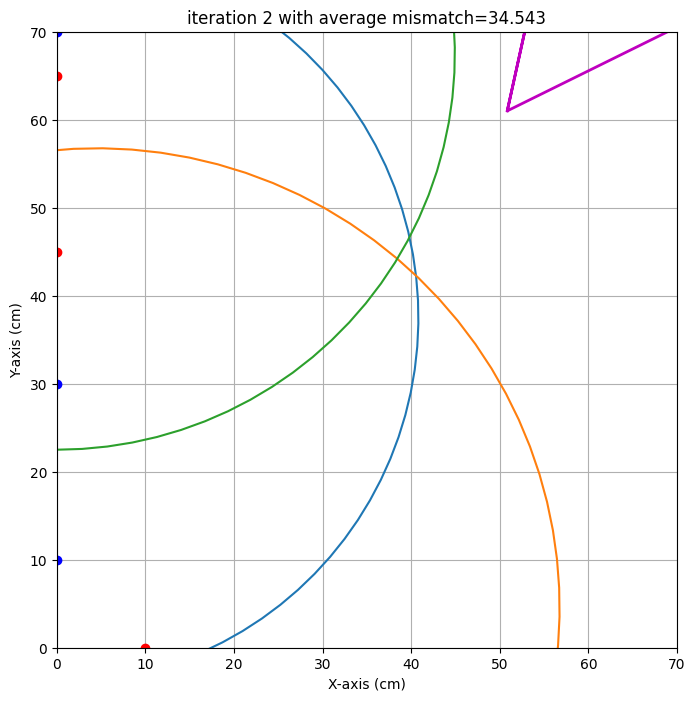

end iteration 2 with average mismatch=34.543


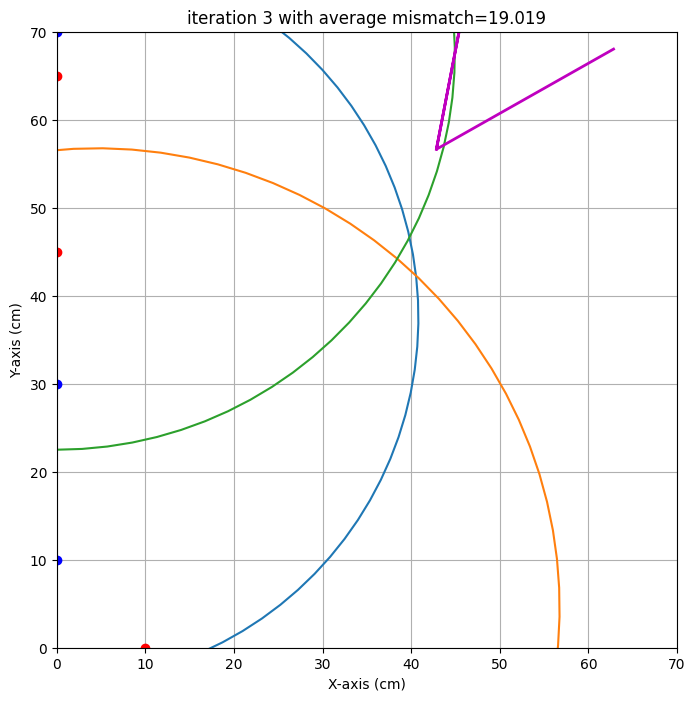

end iteration 3 with average mismatch=19.019


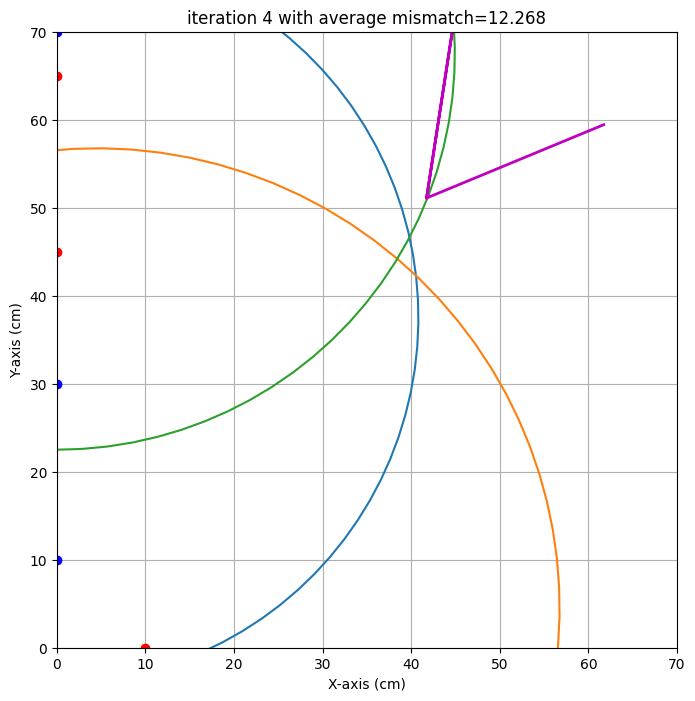

end iteration 4 with average mismatch=12.268


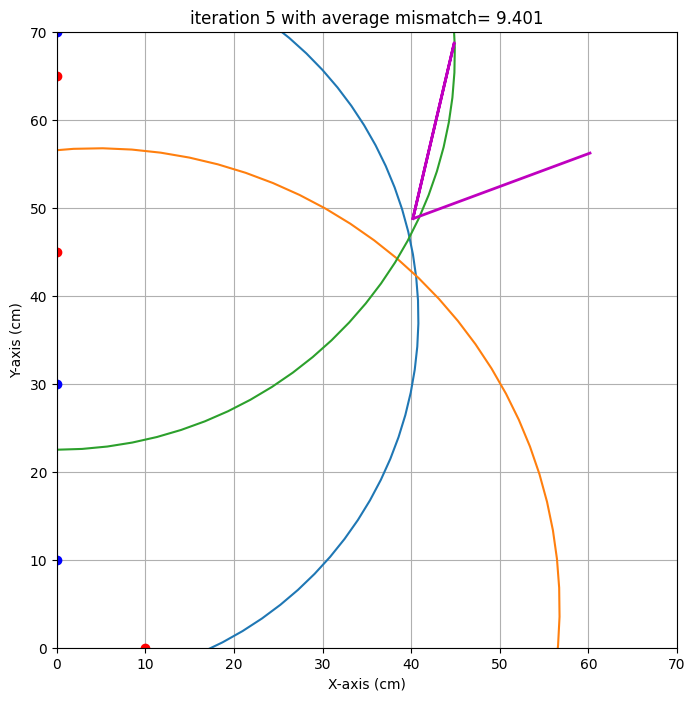

end iteration 5 with average mismatch= 9.401


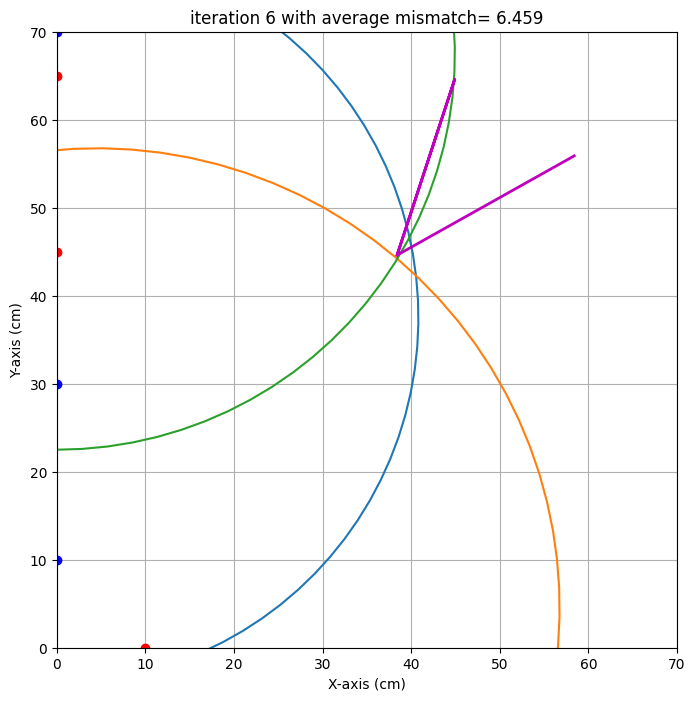

end iteration 6 with average mismatch= 6.459
end iteration 7 with average mismatch= 6.136


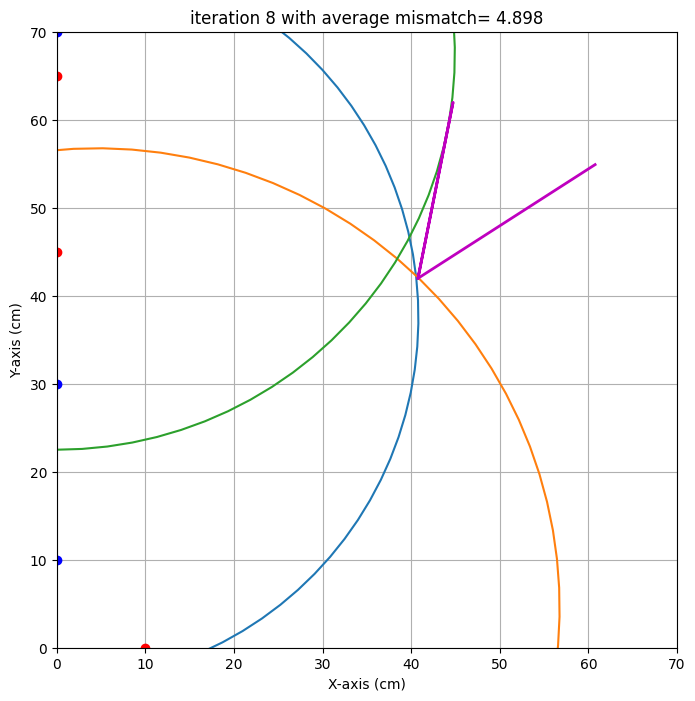

end iteration 8 with average mismatch= 4.898
end iteration 9 with average mismatch= 4.640
end iteration 10 with average mismatch= 4.640
end iteration 11 with average mismatch= 4.640
end iteration 12 with average mismatch= 4.640
end iteration 13 with average mismatch= 4.627
end iteration 14 with average mismatch= 4.617
end iteration 15 with average mismatch= 4.617
end iteration 16 with average mismatch= 4.578
end iteration 17 with average mismatch= 4.438
end iteration 18 with average mismatch= 4.368
end iteration 19 with average mismatch= 4.206
end iteration 20 with average mismatch= 4.200
end iteration 21 with average mismatch= 4.200
end iteration 22 with average mismatch= 4.200
end iteration 23 with average mismatch= 4.200
end iteration 24 with average mismatch= 4.199
end iteration 25 with average mismatch= 4.199
end iteration 26 with average mismatch= 4.199
end iteration 27 with average mismatch= 4.199
end iteration 28 with average mismatch= 4.199
end iteration 29 with average mismat

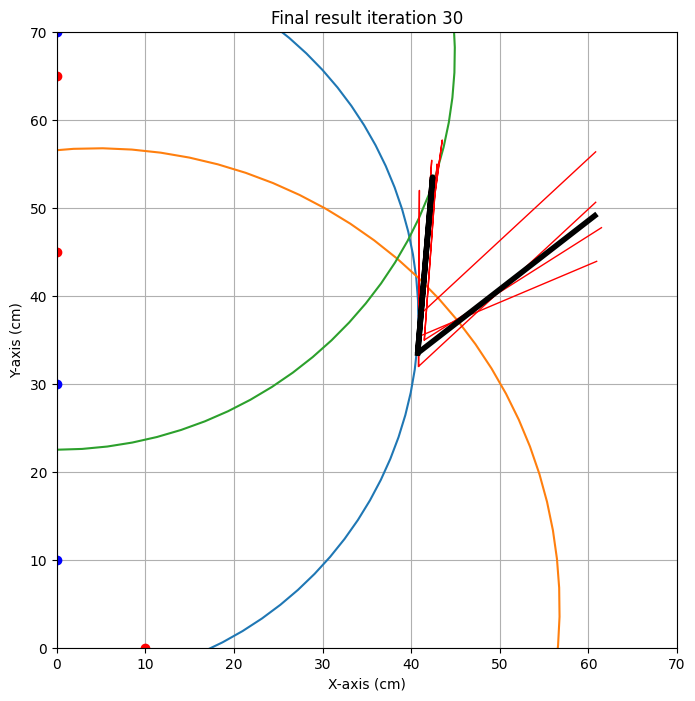

In [6]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,45,0,30,83],
    [10,0,0,10,104],
    #[0,45,0,70,160],
    #[0,55,0,70,160],
    [0,65,0,70,90],
    #[10,0,20,0,170],
    #[10,0,0,10,160]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

## Opdracht 5: Iteratie 0

#### algoritme [Meike]

<img src="algoritme_meike.jpeg" width="400">

#### algoritme [Pepper]
<img src="algoritme_pepper.jpeg" width="400">

#### algoritme [Ebe]
<img src="algoritme_ebe_goede.jpeg" width="400">

Als de afstand groter is dan 160 cm dan is de meting ongeldig.
Daarnaast moet de scherpe hoek naar de oorsprong gericht staan.

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 37.1,  
           'y0':41.2,
           'alpha' : 13,
           'beta' : 13,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={ 'Meike' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,90],
    #[0,40, 0,50, 160],
    #[0,0,10,0, 160],
    [50,0,60,0, 80],
    ]),
       'Pepper' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,60,0,88.5],
    [55,0,70,0,93],
    #[40,0,20,0,160],
    #[25,0,5,0, 160]
    ]),
       'Ebe' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[10,0,20,0,160],
    [40,0,50,0, 86],
    [50,0,60,0, 89],
    #[0,20,0,10, 160],
    [0,50,0,40,80],
    [0,60,0,50,78]
    ])
      }

## Opdracht 7: Evaluatie.

Meike
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  40   0  50   0  90
1  50   0  60   0  80


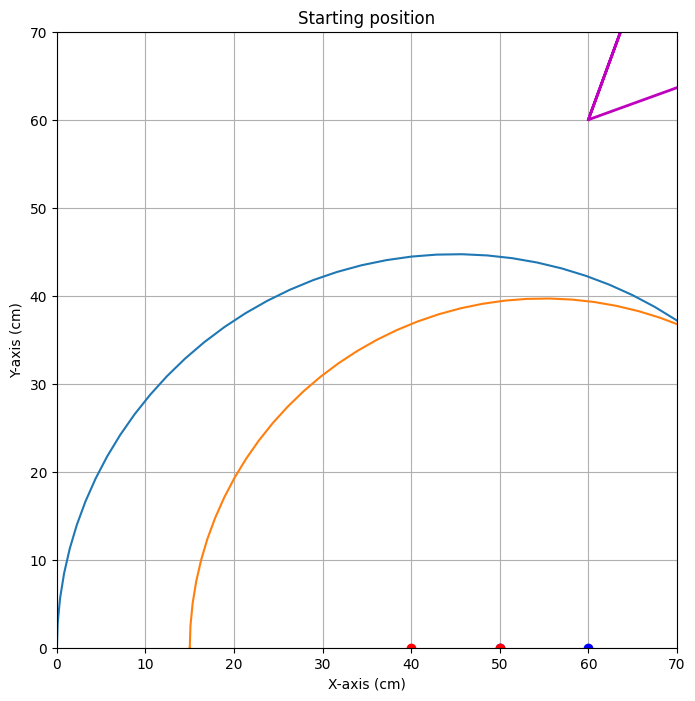


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.952


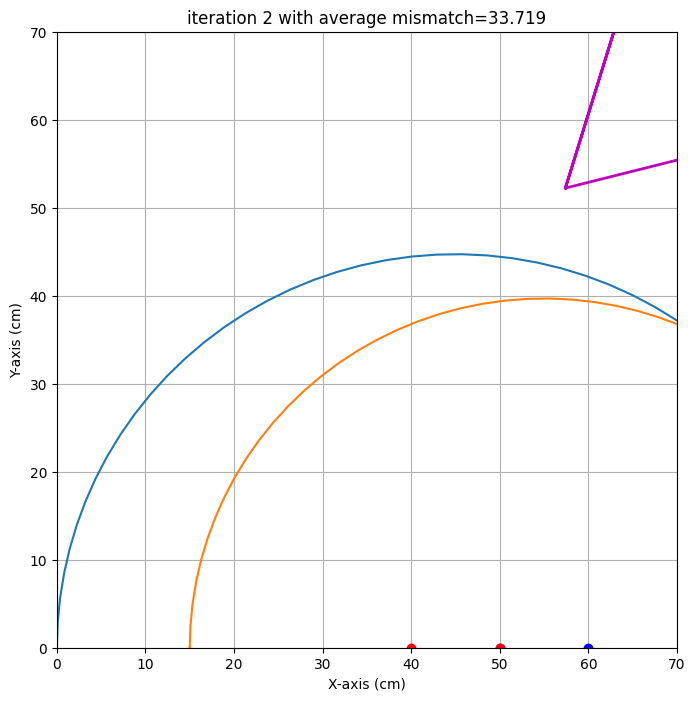

end iteration 2 with average mismatch=33.719


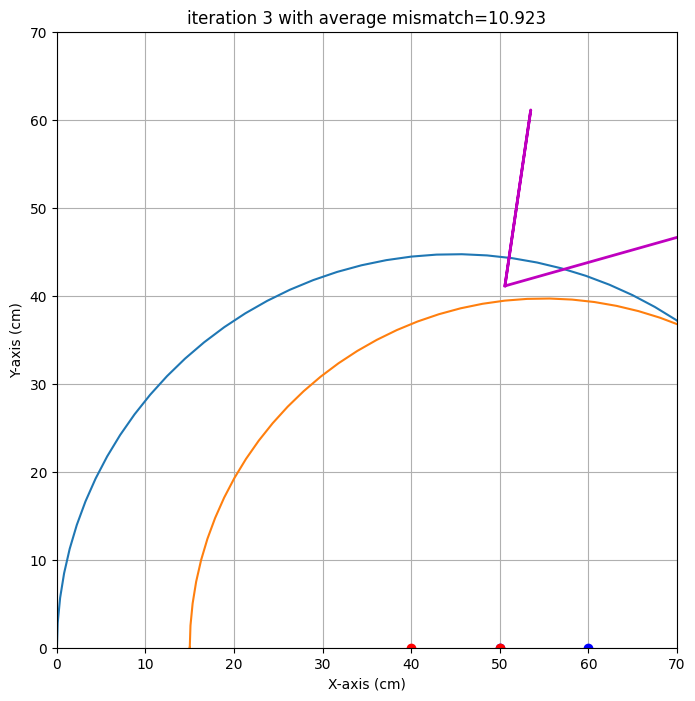

end iteration 3 with average mismatch=10.923


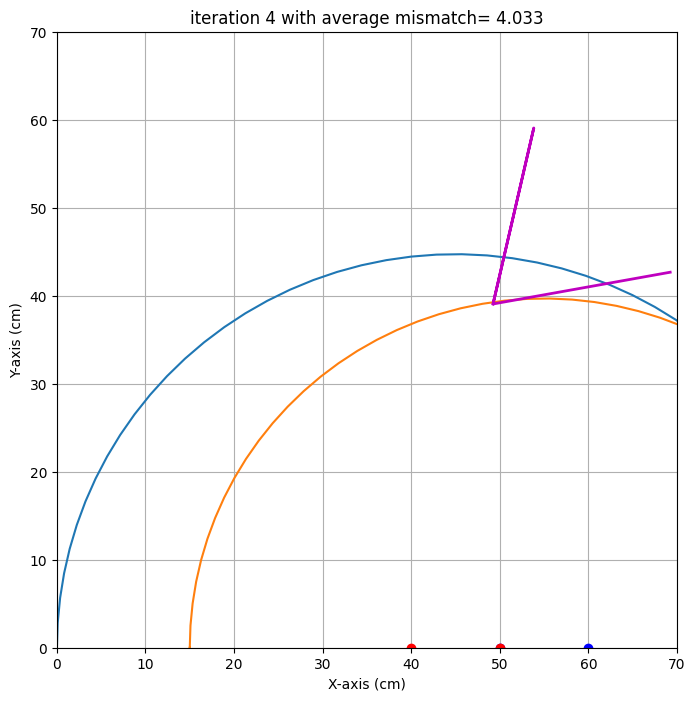

end iteration 4 with average mismatch= 4.033


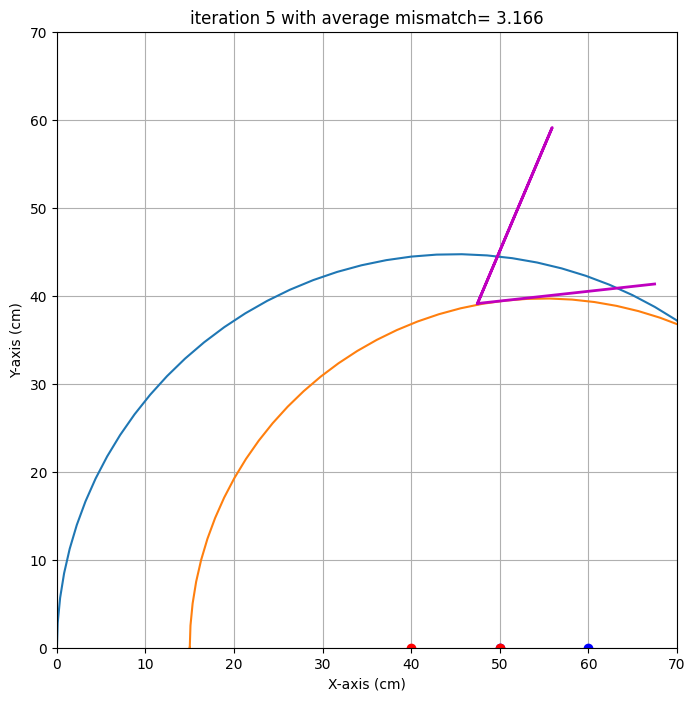

end iteration 5 with average mismatch= 3.166
end iteration 6 with average mismatch= 2.986


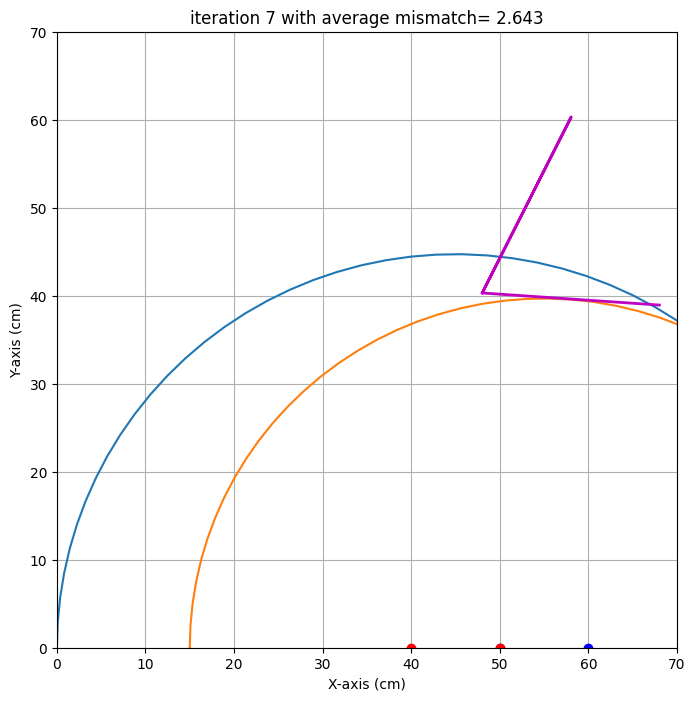

end iteration 7 with average mismatch= 2.643
end iteration 8 with average mismatch= 2.427


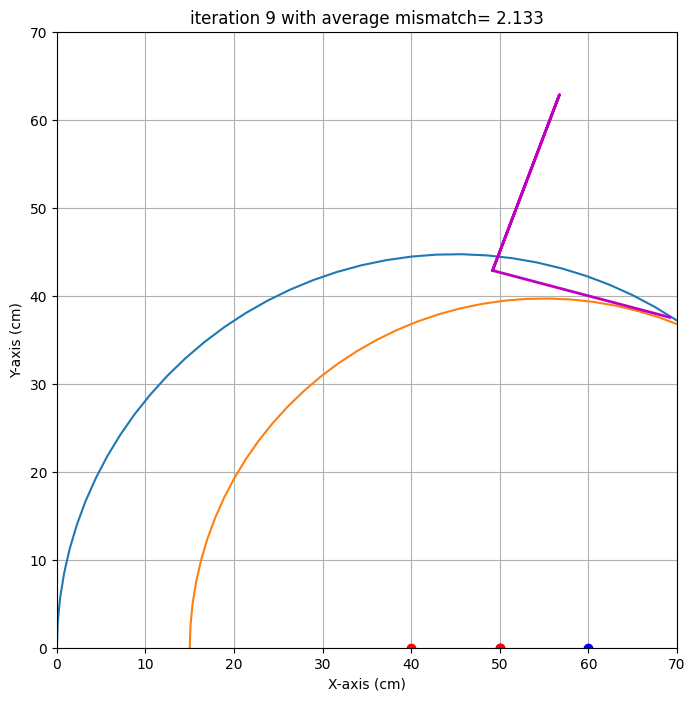

end iteration 9 with average mismatch= 2.133


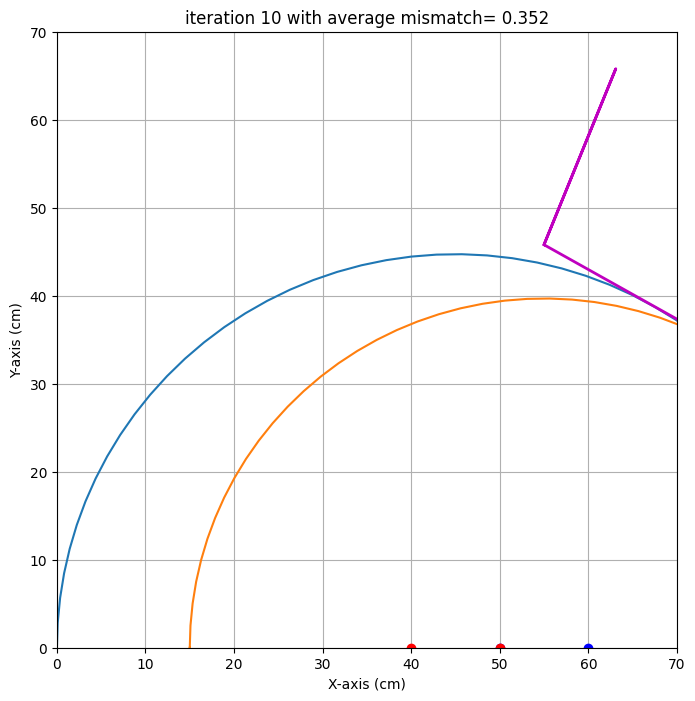

end iteration 10 with average mismatch= 0.352


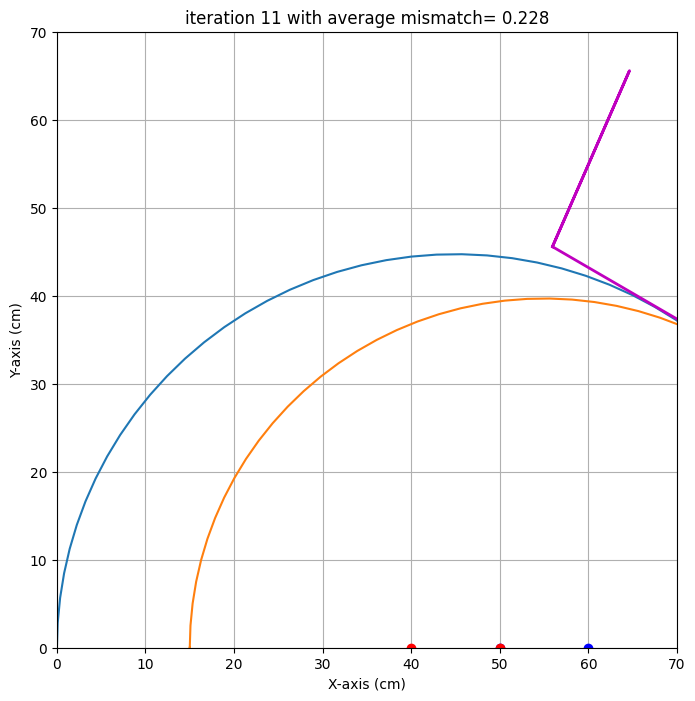

end iteration 11 with average mismatch= 0.228


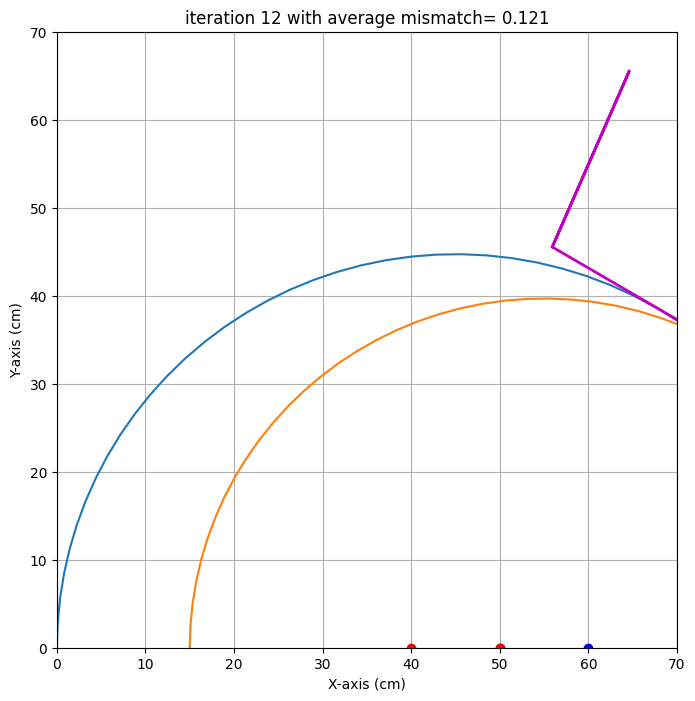

end iteration 12 with average mismatch= 0.121
end iteration 13 with average mismatch= 0.115
end iteration 14 with average mismatch= 0.115
end iteration 15 with average mismatch= 0.115
end iteration 16 with average mismatch= 0.115
end iteration 17 with average mismatch= 0.115
end iteration 18 with average mismatch= 0.115
end iteration 19 with average mismatch= 0.115
end iteration 20 with average mismatch= 0.115
end iteration 21 with average mismatch= 0.115
end iteration 22 with average mismatch= 0.115
end iteration 23 with average mismatch= 0.115
end iteration 24 with average mismatch= 0.108
end iteration 25 with average mismatch= 0.098
end iteration 26 with average mismatch= 0.098
end iteration 27 with average mismatch= 0.098
end iteration 28 with average mismatch= 0.098
end iteration 29 with average mismatch= 0.098
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.098
#################

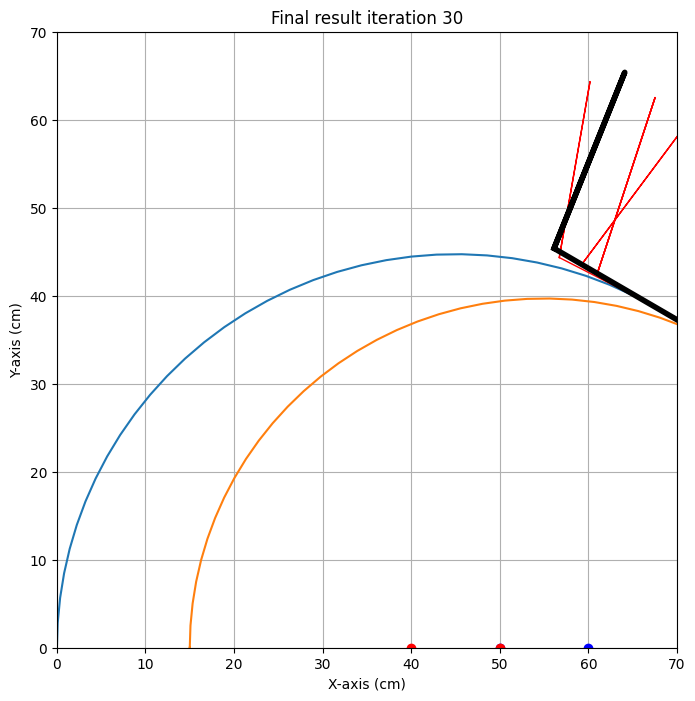

{'alpha': np.float64(-30.30035192805293), 'alpha_eps': np.float64(3.0426507519164048), 'beta': np.float64(21.768967450840435), 'beta_eps': np.float64(14.791442333653613), 'x0': np.float64(56.12572154676062), 'x0_eps': np.float64(4.882470505900216), 'y0': np.float64(45.38397162730333), 'y0_eps': np.float64(2.862370635439099)}
Pepper
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  60   0  88.5
1  55   0  70   0  93.0


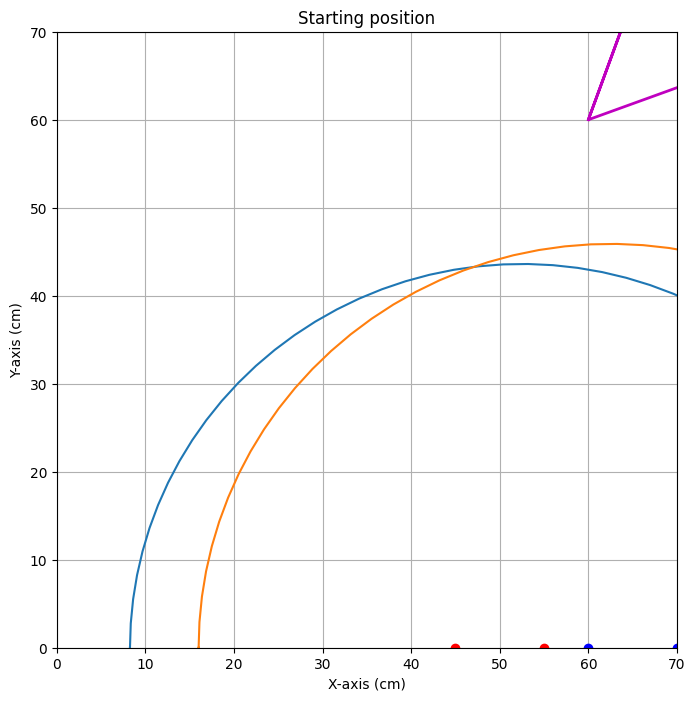


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.786


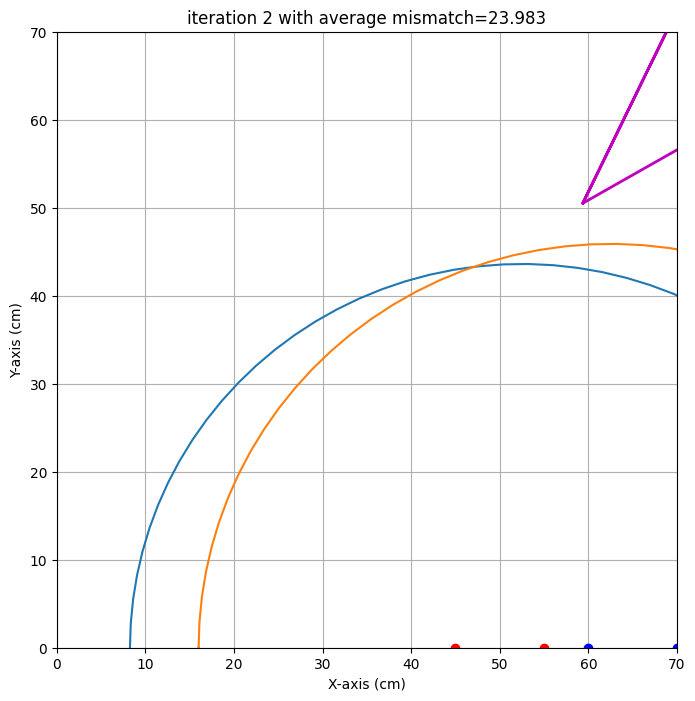

end iteration 2 with average mismatch=23.983


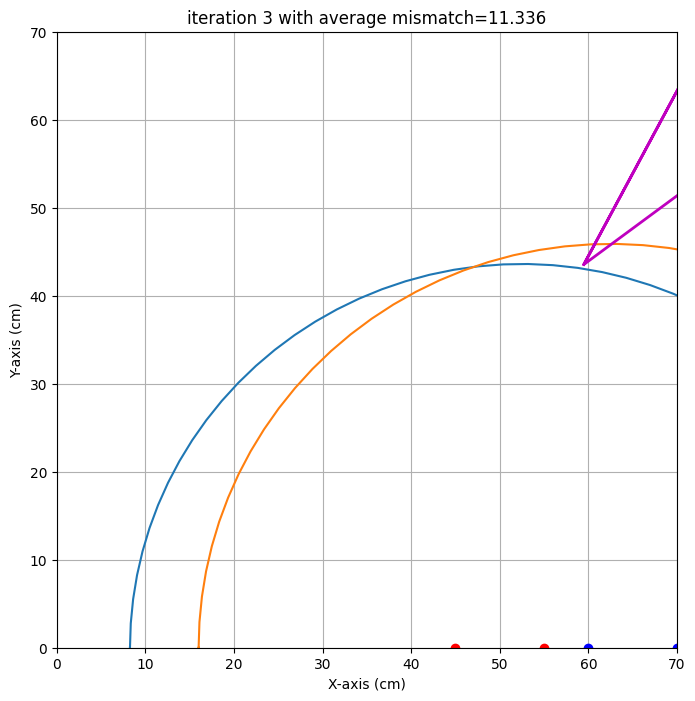

end iteration 3 with average mismatch=11.336


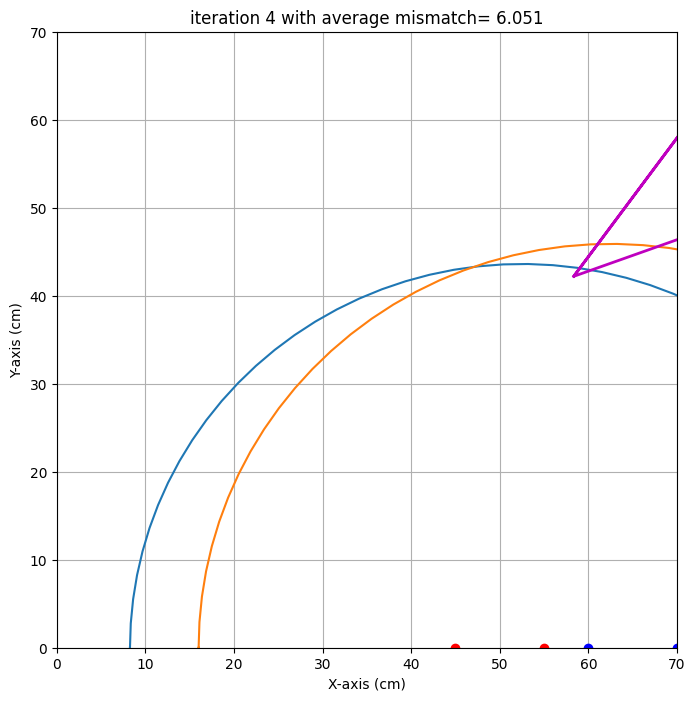

end iteration 4 with average mismatch= 6.051


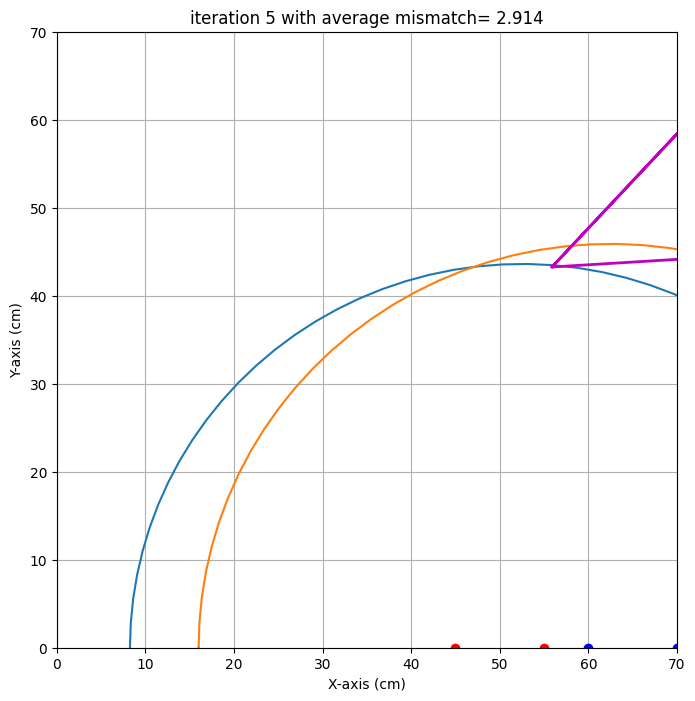

end iteration 5 with average mismatch= 2.914
end iteration 6 with average mismatch= 2.666


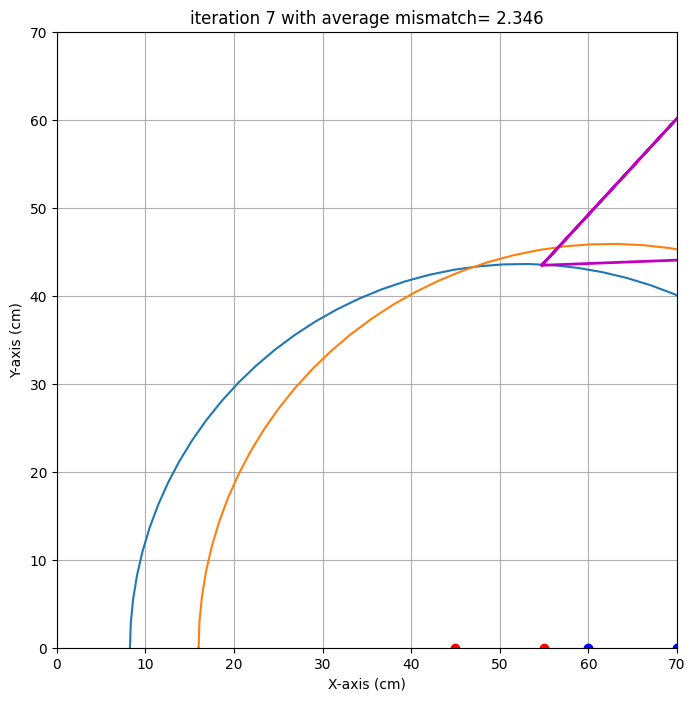

end iteration 7 with average mismatch= 2.346
end iteration 8 with average mismatch= 2.298
end iteration 9 with average mismatch= 2.298
end iteration 10 with average mismatch= 2.204
end iteration 11 with average mismatch= 2.109
end iteration 12 with average mismatch= 2.109
end iteration 13 with average mismatch= 2.004
end iteration 14 with average mismatch= 2.004
end iteration 15 with average mismatch= 2.004
end iteration 16 with average mismatch= 1.845
end iteration 17 with average mismatch= 1.832
end iteration 18 with average mismatch= 1.689
end iteration 19 with average mismatch= 1.689
end iteration 20 with average mismatch= 1.689
end iteration 21 with average mismatch= 1.639


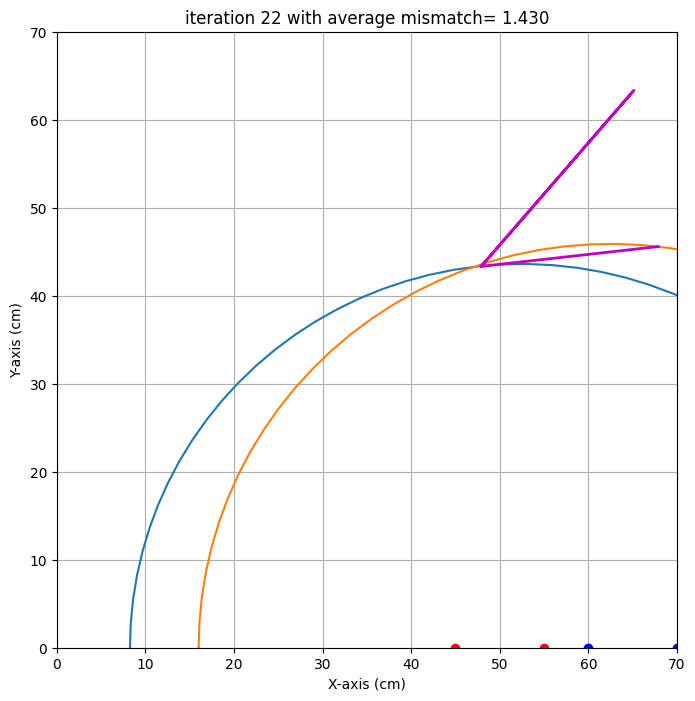

end iteration 22 with average mismatch= 1.430
end iteration 23 with average mismatch= 1.430
end iteration 24 with average mismatch= 1.326


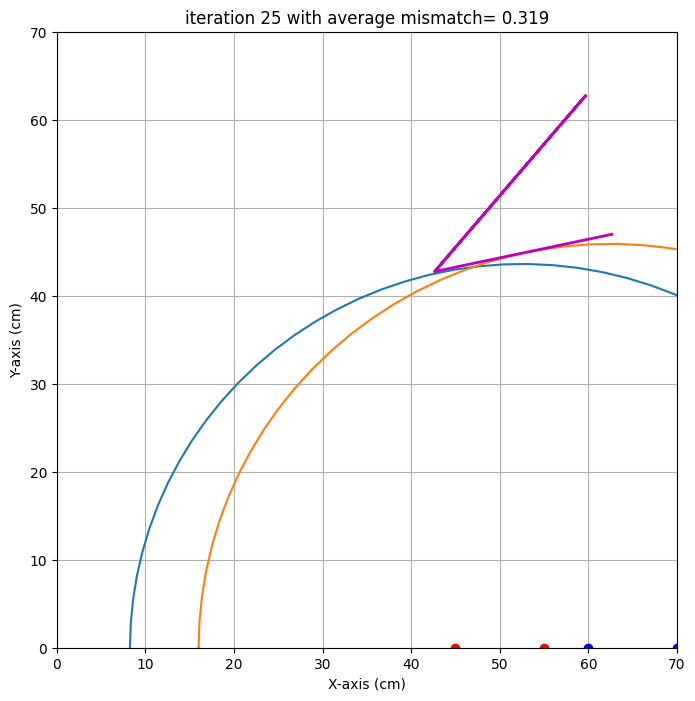

end iteration 25 with average mismatch= 0.319


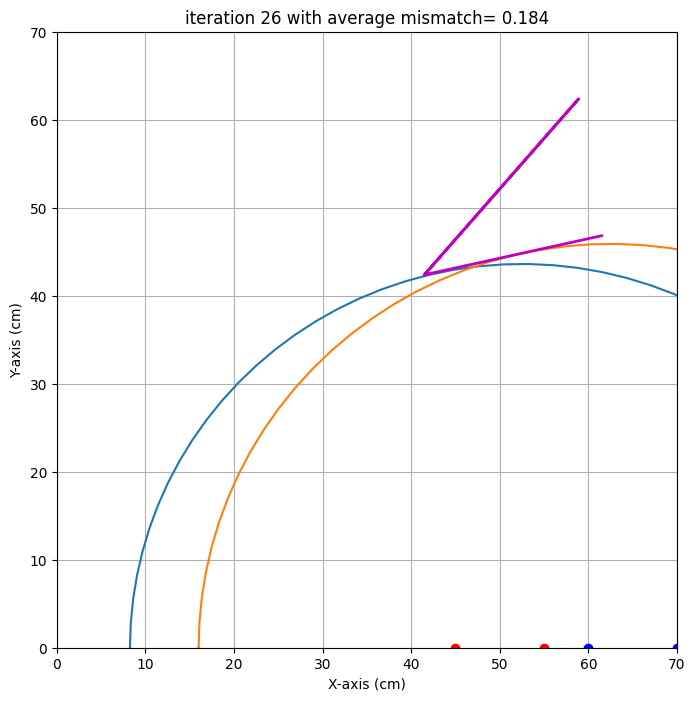

end iteration 26 with average mismatch= 0.184


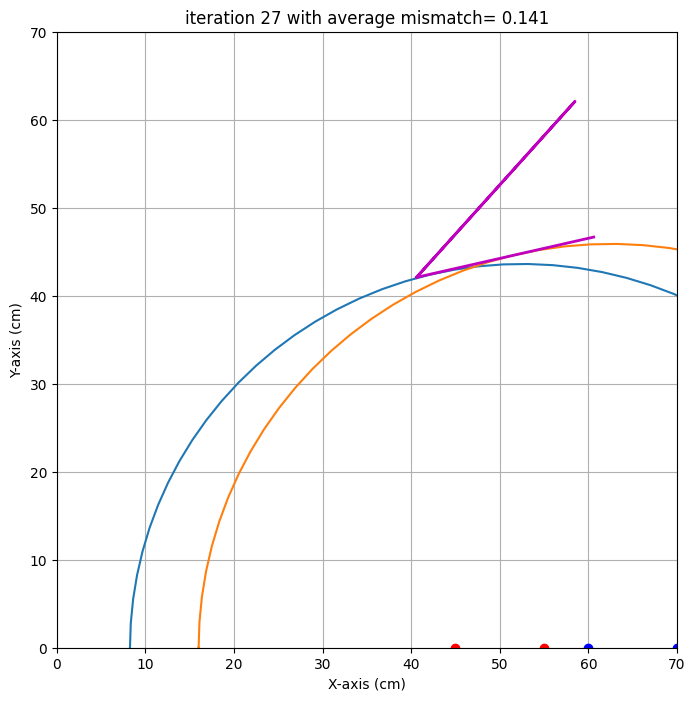

end iteration 27 with average mismatch= 0.141


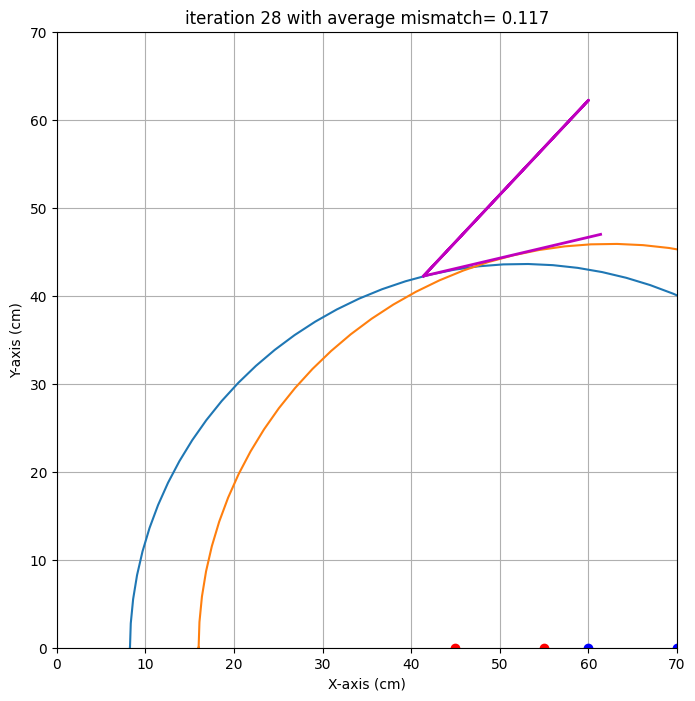

end iteration 28 with average mismatch= 0.117
end iteration 29 with average mismatch= 0.117
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.117
###############################################################################
end of iteration  30
Best alpha=  13.33 with uncertainty=   2.39
Best beta =  43.00 with uncertainty=  12.63
Best x0   =  41.38 with uncertainty=   4.99
Best y0   =  42.23 with uncertainty=   1.18
###############################################################################


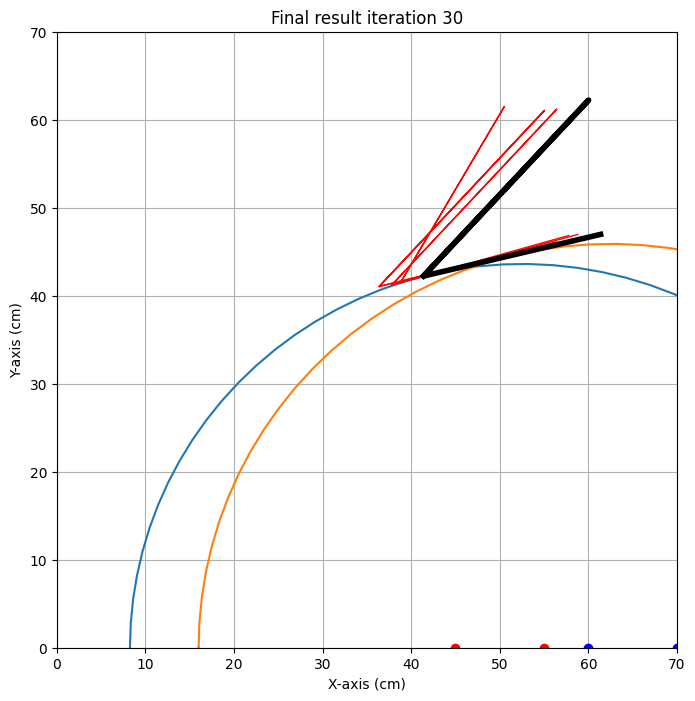

{'alpha': np.float64(13.33379685359164), 'alpha_eps': np.float64(2.3870177266275228), 'beta': np.float64(43.0), 'beta_eps': np.float64(12.634755947772732), 'x0': np.float64(41.38271726444201), 'x0_eps': np.float64(4.988561100398272), 'y0': np.float64(42.23076319140625), 'y0_eps': np.float64(1.1755209765371077)}
Ebe
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  40   0  50   0  86
1  50   0  60   0  89
2   0  50   0  40  80
3   0  60   0  50  78


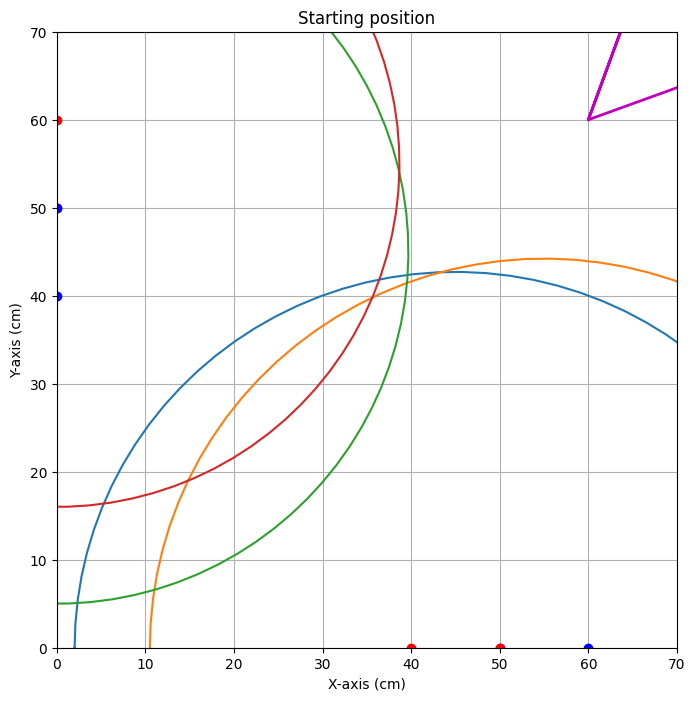


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.323


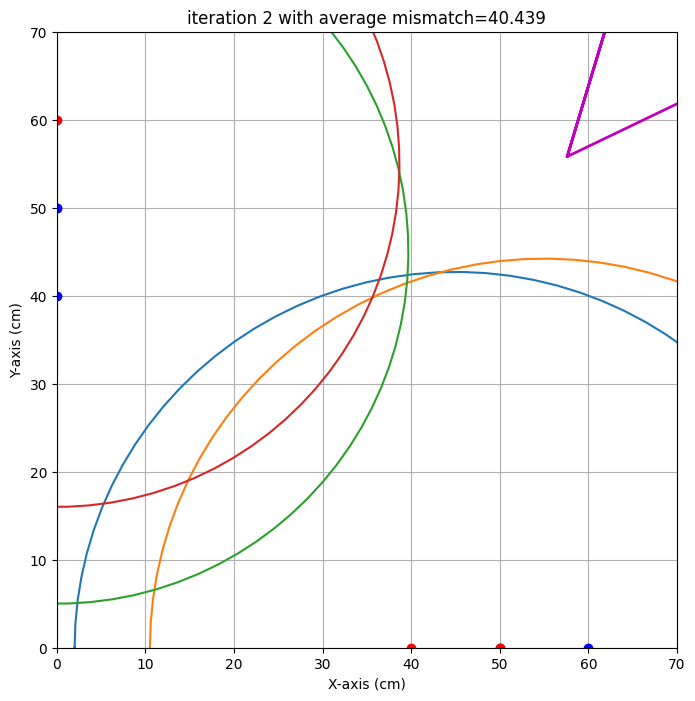

end iteration 2 with average mismatch=40.439


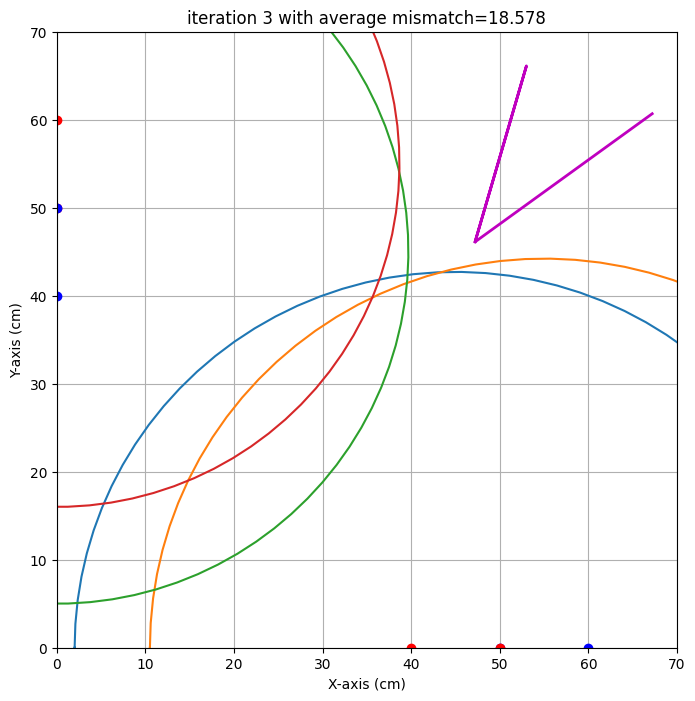

end iteration 3 with average mismatch=18.578


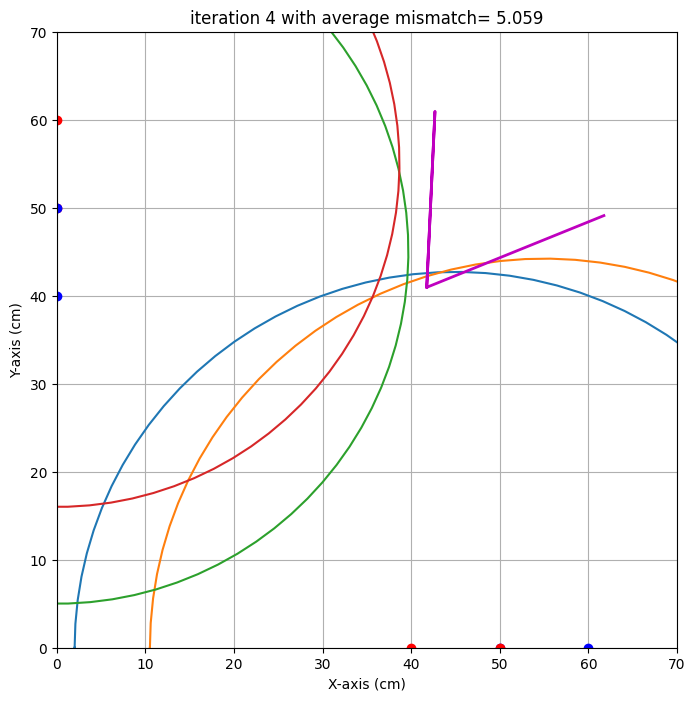

end iteration 4 with average mismatch= 5.059


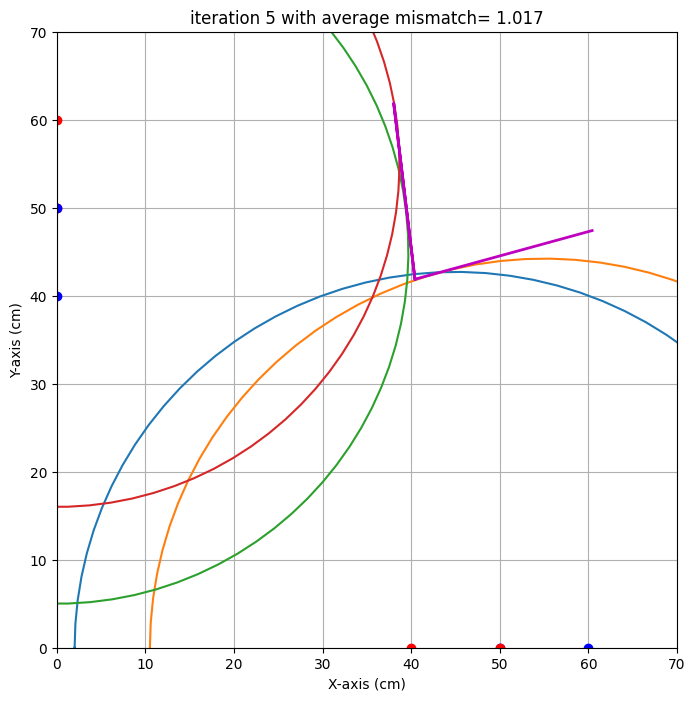

end iteration 5 with average mismatch= 1.017
end iteration 6 with average mismatch= 1.011


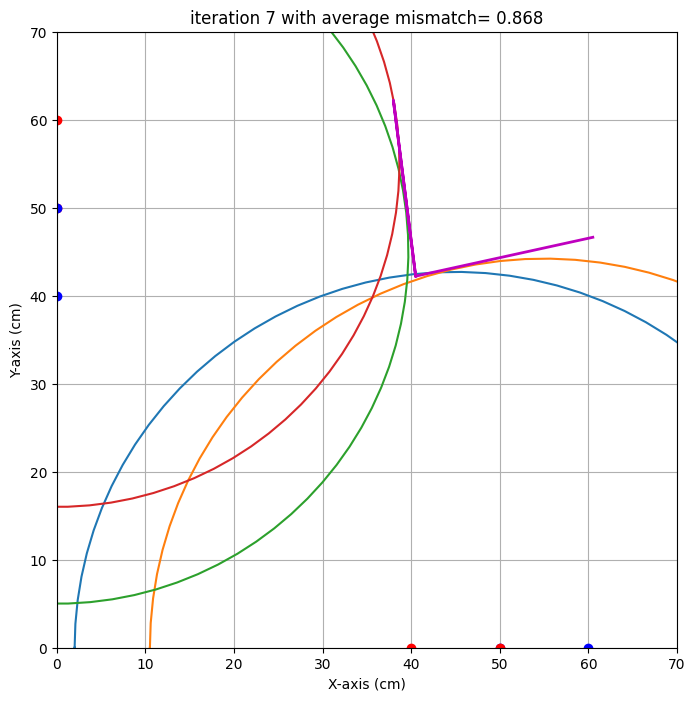

end iteration 7 with average mismatch= 0.868
end iteration 8 with average mismatch= 0.852
end iteration 9 with average mismatch= 0.849


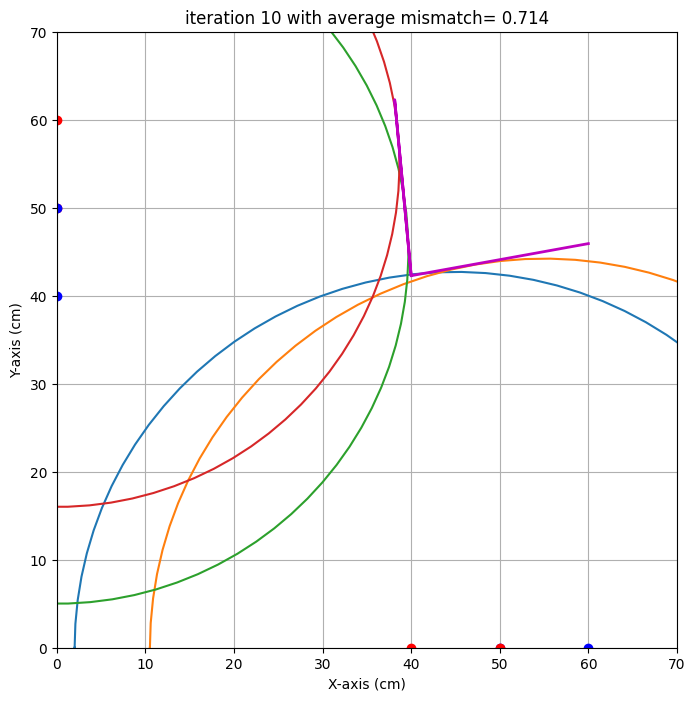

end iteration 10 with average mismatch= 0.714


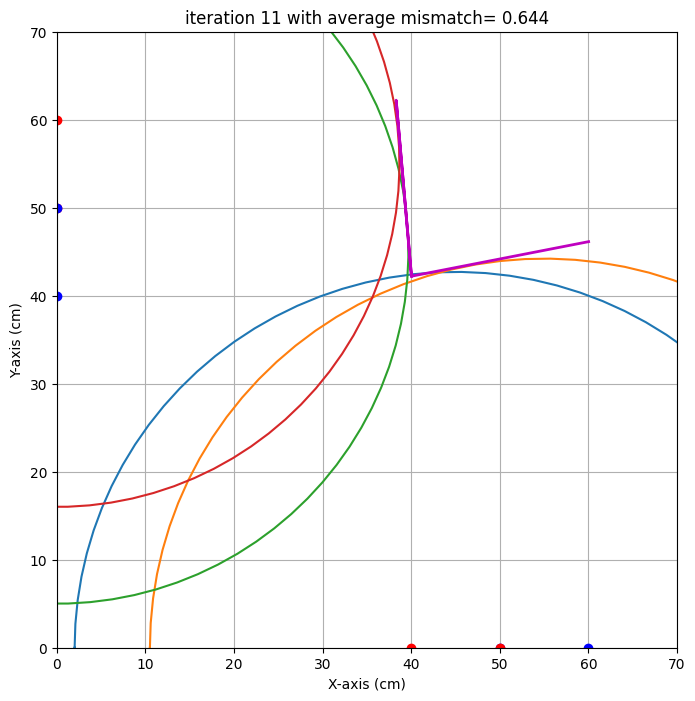

end iteration 11 with average mismatch= 0.644
end iteration 12 with average mismatch= 0.582
end iteration 13 with average mismatch= 0.573
end iteration 14 with average mismatch= 0.569
end iteration 15 with average mismatch= 0.569
end iteration 16 with average mismatch= 0.569
end iteration 17 with average mismatch= 0.569
end iteration 18 with average mismatch= 0.569
end iteration 19 with average mismatch= 0.569
end iteration 20 with average mismatch= 0.569
end iteration 21 with average mismatch= 0.569


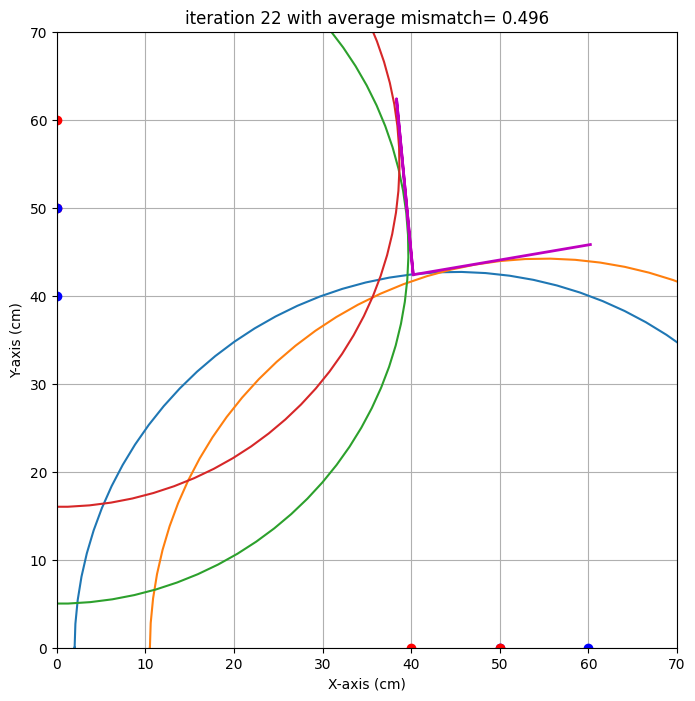

end iteration 22 with average mismatch= 0.496
end iteration 23 with average mismatch= 0.487
end iteration 24 with average mismatch= 0.487
end iteration 25 with average mismatch= 0.480
end iteration 26 with average mismatch= 0.480
end iteration 27 with average mismatch= 0.480
end iteration 28 with average mismatch= 0.480
end iteration 29 with average mismatch= 0.480
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.480
###############################################################################
end of iteration  30
Best alpha=   9.15 with uncertainty=   4.38
Best beta =  -6.51 with uncertainty=   2.69
Best x0   =  40.42 with uncertainty=   0.58
Best y0   =  42.40 with uncertainty=   0.75
###############################################################################


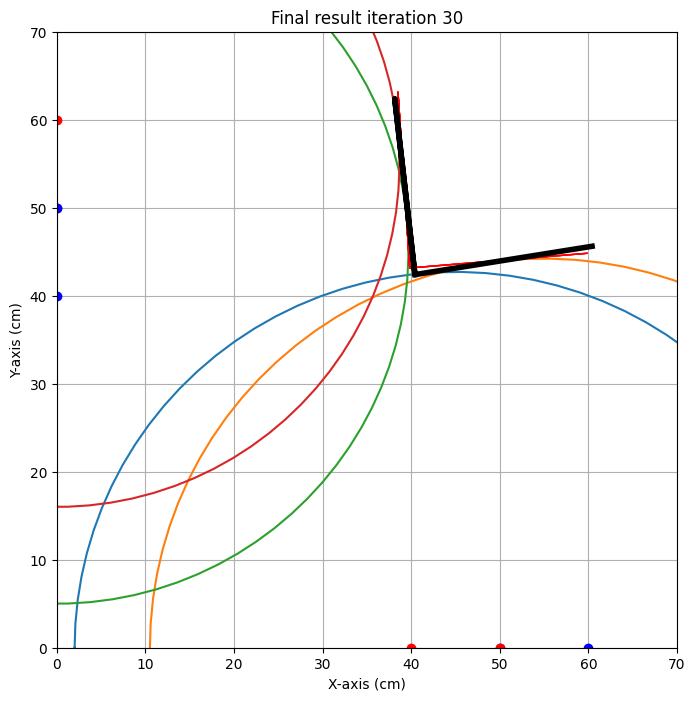

{'alpha': np.float64(9.145478733203808), 'alpha_eps': np.float64(4.378485388372618), 'beta': np.float64(-6.512840167154835), 'beta_eps': np.float64(2.694761248353134), 'x0': np.float64(40.42301435370801), 'x0_eps': np.float64(0.5812932006779334), 'y0': np.float64(42.399300513737), 'y0_eps': np.float64(0.7527090007231791)}


In [9]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [10]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Meike 
x0 target is : 37.1. Gevonden waarde: 56.1 cm met een standaardafwijking van 4.9 cm 
y0 target is : 41.2. Gevonden waarde: 45.4 cm met een standaardafwijking van 2.9 cm 
alpha target is : 13.0. Gevonden waarde: -30.3 graden met een standaardafwijking van 3.0 graad 
beta target is : 13.0. Gevonden waarde: 21.8 graden met een standaardafwijking van 14.8 graad 

Pepper 
x0 target is : 37.1. Gevonden waarde: 41.4 cm met een standaardafwijking van 5.0 cm 
y0 target is : 41.2. Gevonden waarde: 42.2 cm met een standaardafwijking van 1.2 cm 
alpha target is : 13.0. Gevonden waarde: 13.3 graden met een standaardafwijking van 2.4 graad 
beta target is : 13.0. Gevonden waarde: 43.0 graden met een standaardafwijking van 12.6 graad 

Ebe 
x0 target is : 37.1. Gevonden waarde: 40.4 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.2. Gevonden waarde: 42.4 cm met een standaardafwijking van 0.8 cm 
alpha target is : 13.0. Gevonden waarde: 9.1 graden met een standaardafwijking van 4.4 

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg)


In [11]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  90.0
1  50   0  60   0  95.0
2  30   0  40   0  98.0
3   0  40   0  50  69.0
4   0  60   0  70  63.0
5   0  50   0  60  65.5


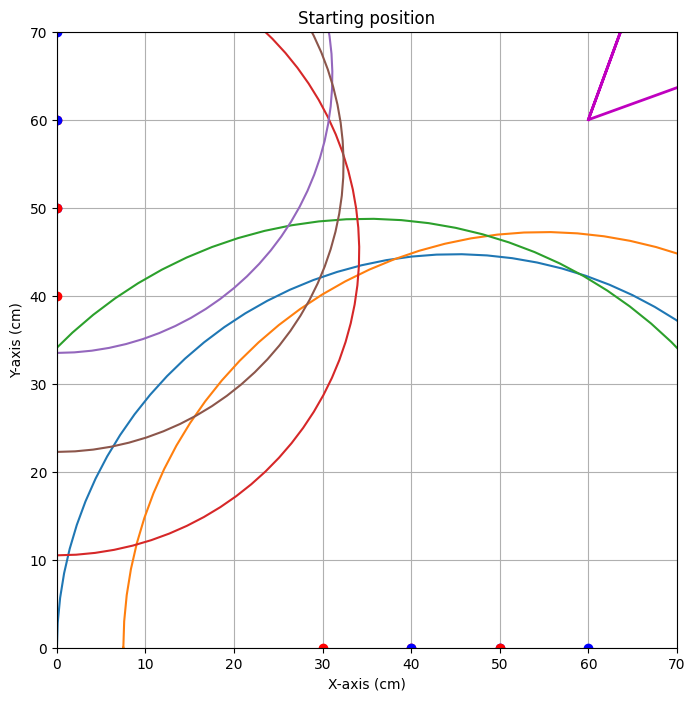


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.131


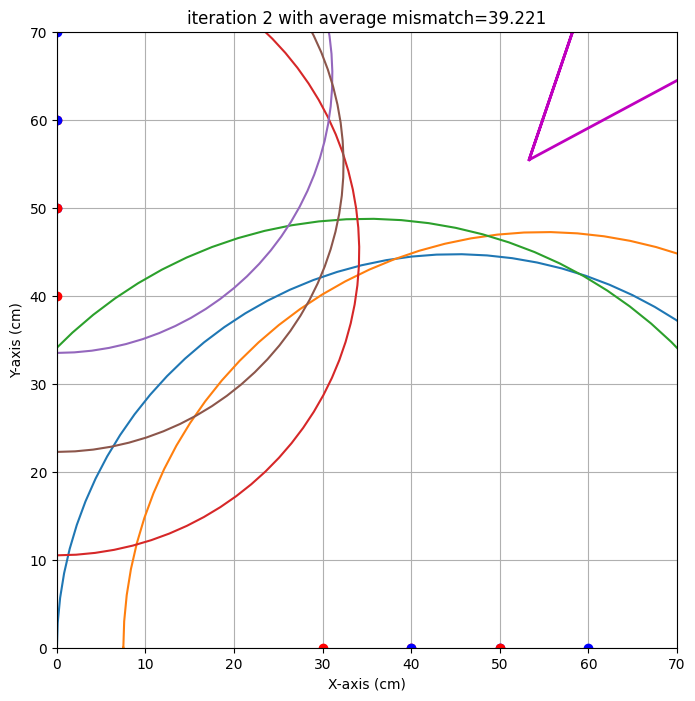

end iteration 2 with average mismatch=39.221


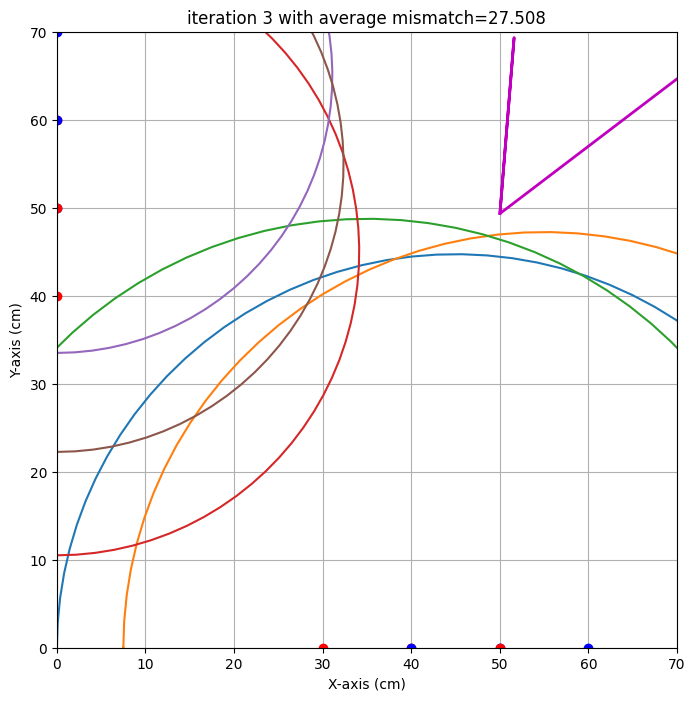

end iteration 3 with average mismatch=27.508


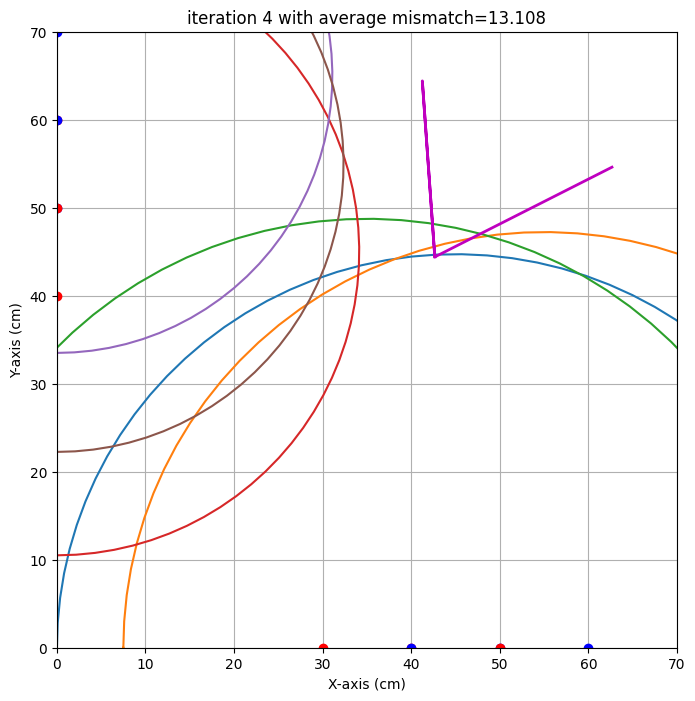

end iteration 4 with average mismatch=13.108


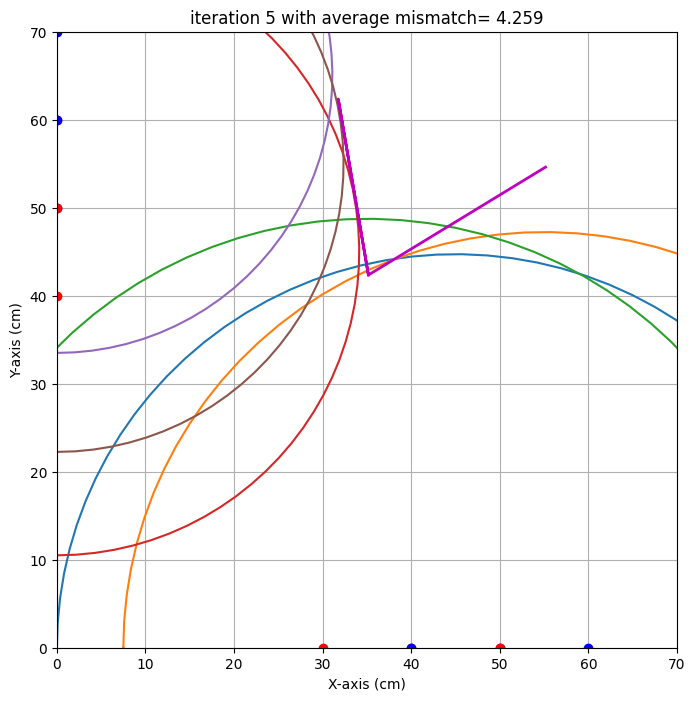

end iteration 5 with average mismatch= 4.259


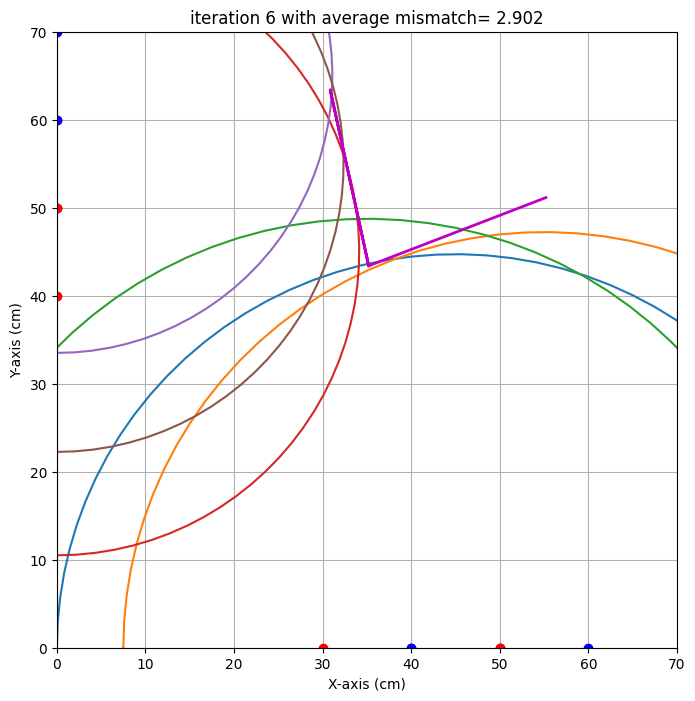

end iteration 6 with average mismatch= 2.902
end iteration 7 with average mismatch= 2.645
end iteration 8 with average mismatch= 2.645
end iteration 9 with average mismatch= 2.641
end iteration 10 with average mismatch= 2.641


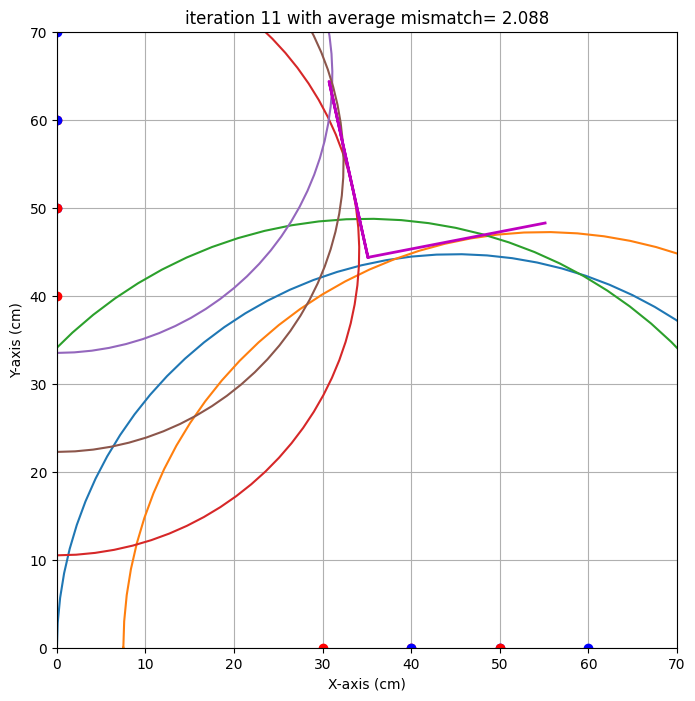

end iteration 11 with average mismatch= 2.088
end iteration 12 with average mismatch= 2.088
end iteration 13 with average mismatch= 2.088
end iteration 14 with average mismatch= 2.088
end iteration 15 with average mismatch= 2.088
end iteration 16 with average mismatch= 2.088
end iteration 17 with average mismatch= 2.020
end iteration 18 with average mismatch= 2.020
end iteration 19 with average mismatch= 2.020
end iteration 20 with average mismatch= 2.020
end iteration 21 with average mismatch= 2.005
end iteration 22 with average mismatch= 2.005
end iteration 23 with average mismatch= 2.004
end iteration 24 with average mismatch= 2.004
end iteration 25 with average mismatch= 2.004
end iteration 26 with average mismatch= 2.003
end iteration 27 with average mismatch= 1.972
end iteration 28 with average mismatch= 1.972
end iteration 29 with average mismatch= 1.875
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

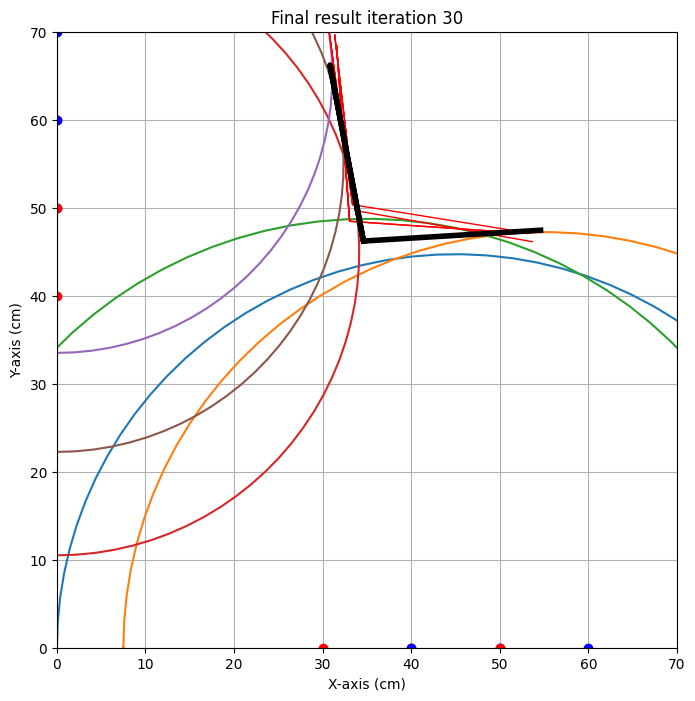

{'alpha': np.float64(3.52264975145854), 'alpha_eps': np.float64(13.553617865444263), 'beta': np.float64(-10.682280990354792), 'beta_eps': np.float64(6.453541980578332), 'x0': np.float64(34.60621089249142), 'x0_eps': np.float64(1.5558149943626631), 'y0': np.float64(46.21233832210427), 'y0_eps': np.float64(4.136103929231396)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  60   0  70   0  100.0
1   0  50   0  60   96.5
2   0  60   0  70   98.0


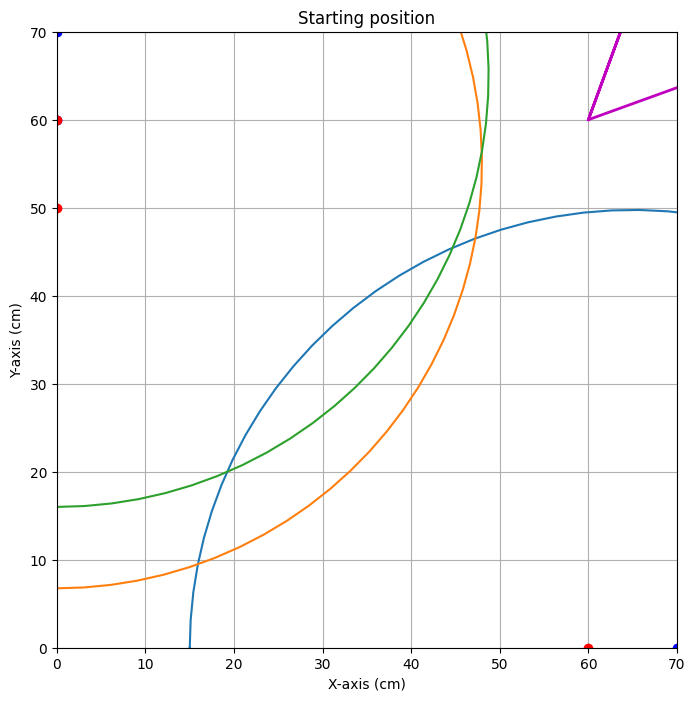


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...



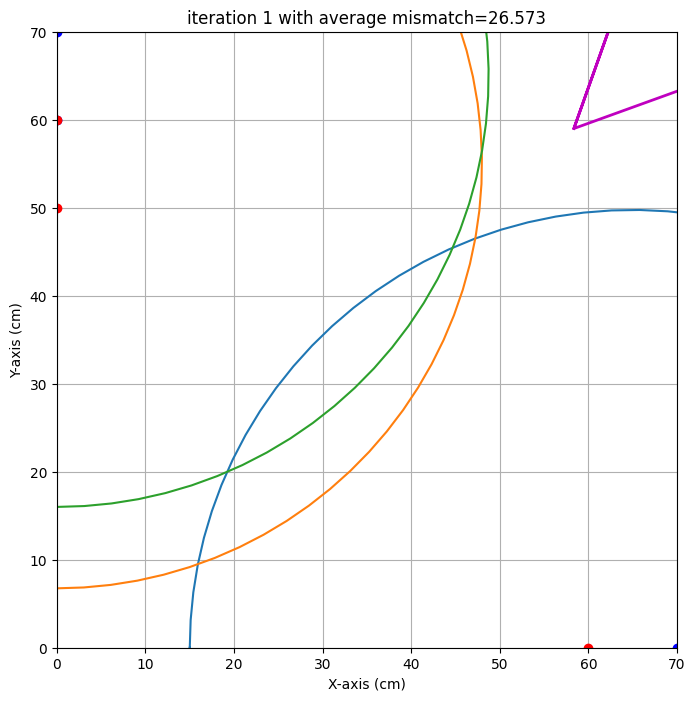

end iteration 1 with average mismatch=26.573


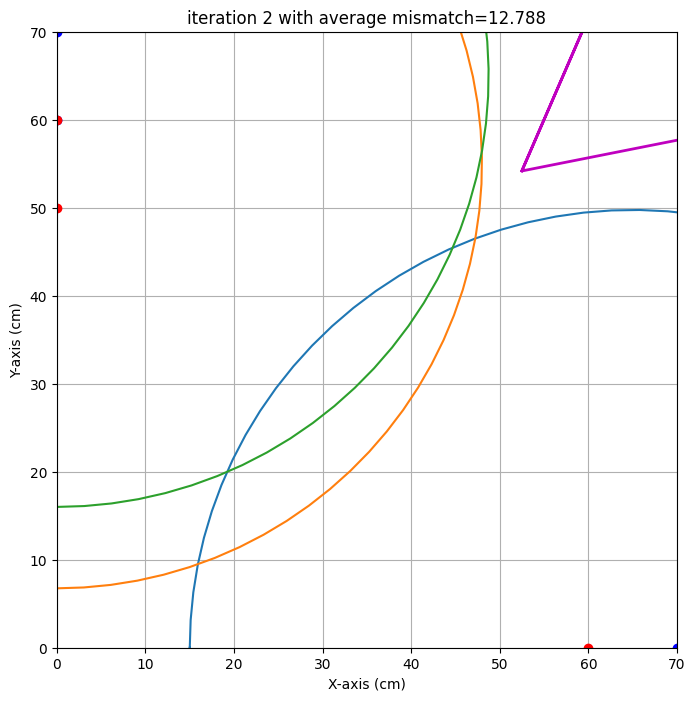

end iteration 2 with average mismatch=12.788


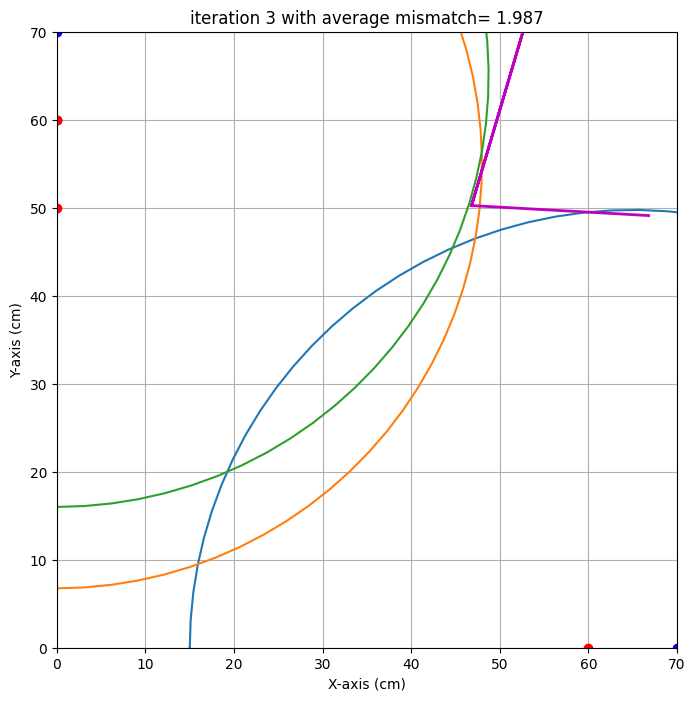

end iteration 3 with average mismatch= 1.987


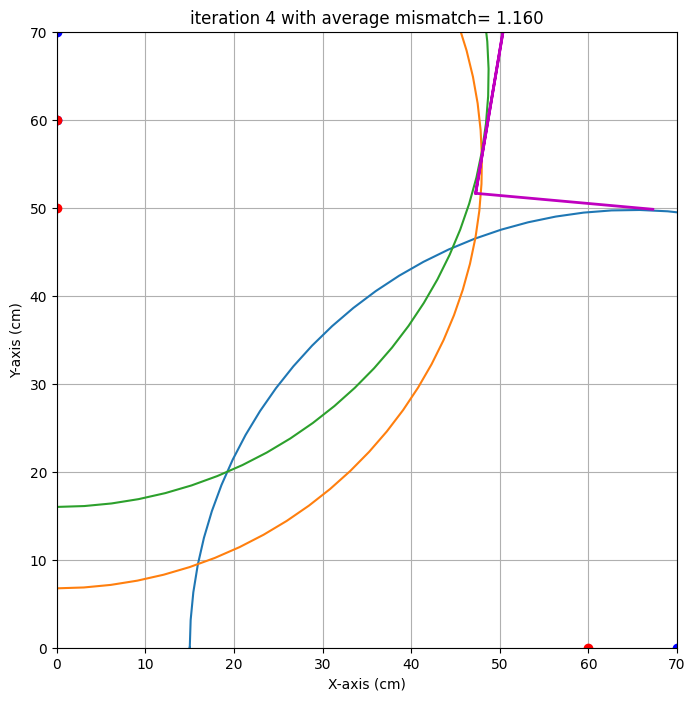

end iteration 4 with average mismatch= 1.160


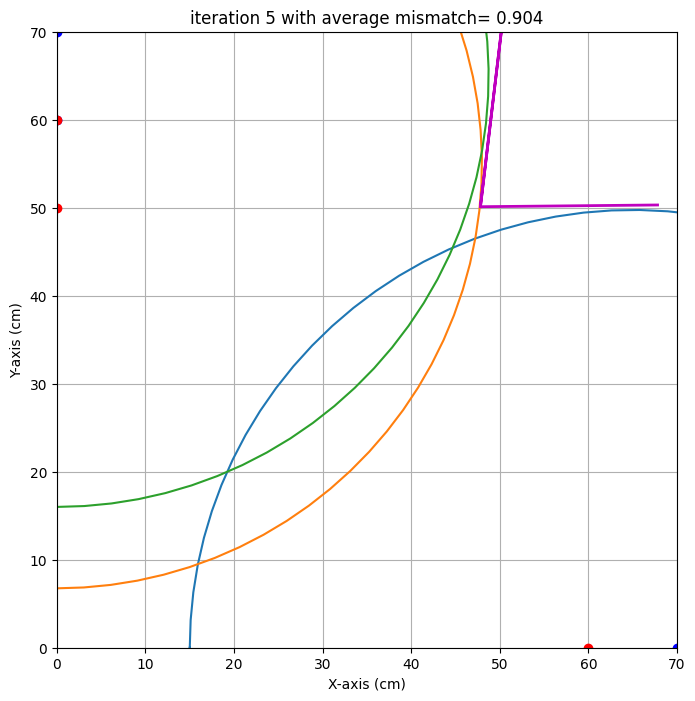

end iteration 5 with average mismatch= 0.904


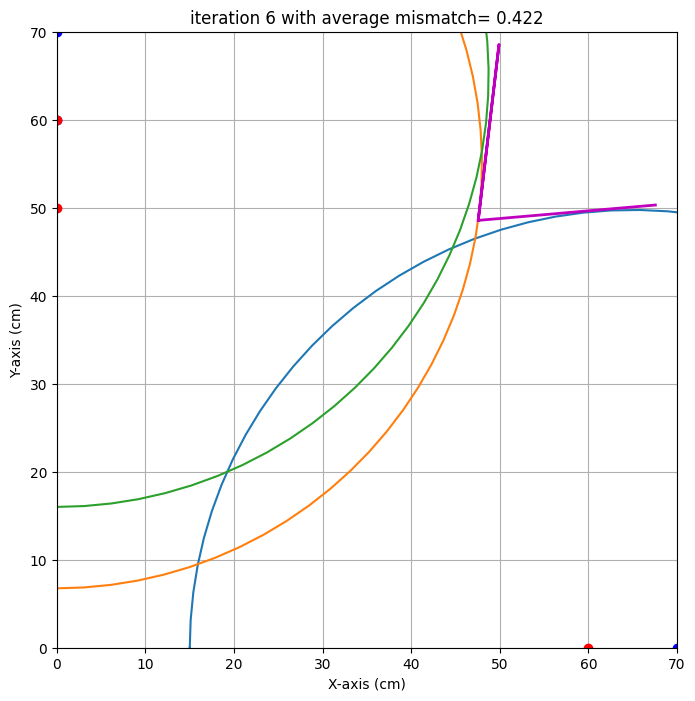

end iteration 6 with average mismatch= 0.422


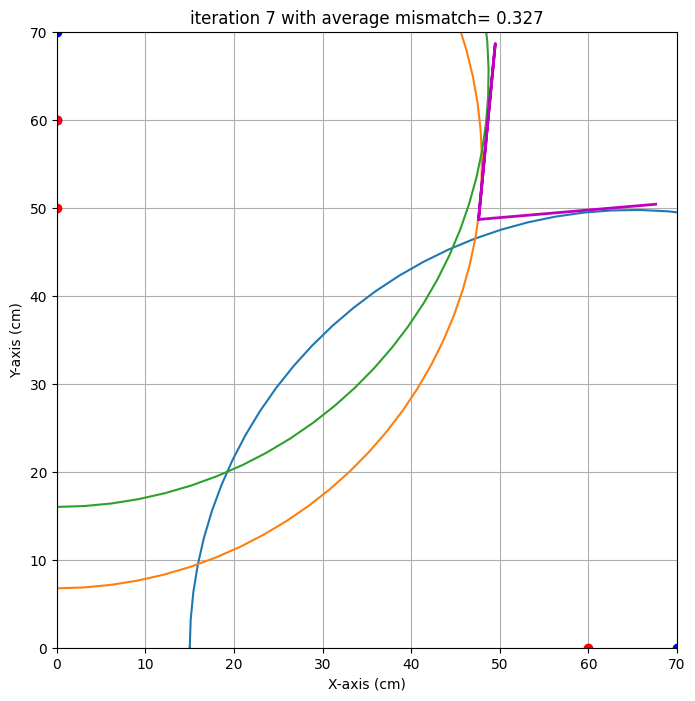

end iteration 7 with average mismatch= 0.327
end iteration 8 with average mismatch= 0.325
end iteration 9 with average mismatch= 0.325
end iteration 10 with average mismatch= 0.296


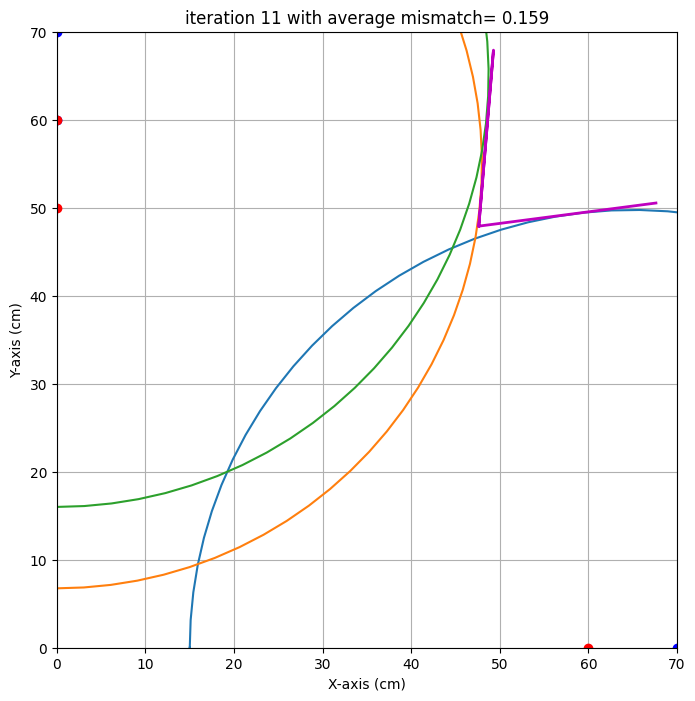

end iteration 11 with average mismatch= 0.159
end iteration 12 with average mismatch= 0.150
end iteration 13 with average mismatch= 0.148
end iteration 14 with average mismatch= 0.137
end iteration 15 with average mismatch= 0.137
end iteration 16 with average mismatch= 0.137
end iteration 17 with average mismatch= 0.137
end iteration 18 with average mismatch= 0.137
end iteration 19 with average mismatch= 0.137
end iteration 20 with average mismatch= 0.137
end iteration 21 with average mismatch= 0.137
end iteration 22 with average mismatch= 0.137
end iteration 23 with average mismatch= 0.137
end iteration 24 with average mismatch= 0.137
end iteration 25 with average mismatch= 0.137
end iteration 26 with average mismatch= 0.137
end iteration 27 with average mismatch= 0.137
end iteration 28 with average mismatch= 0.137
end iteration 29 with average mismatch= 0.137
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

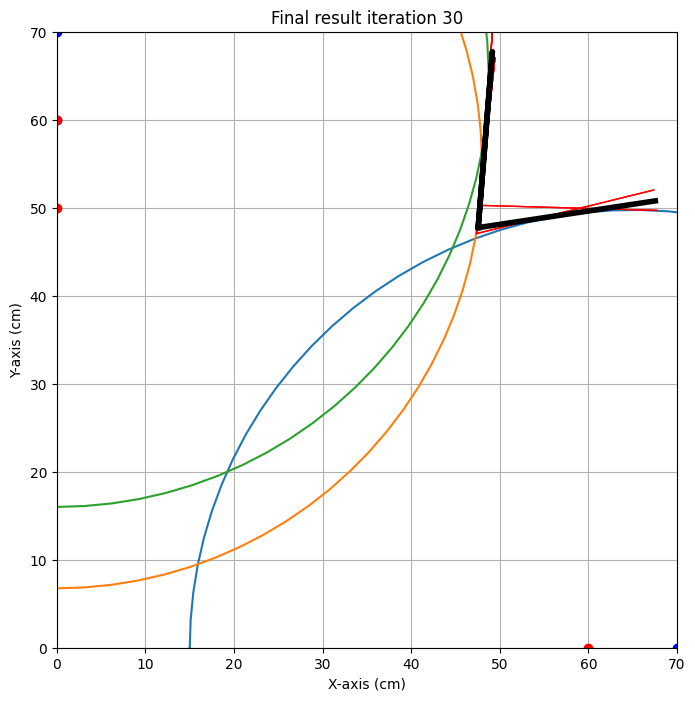

{'alpha': np.float64(8.641394249196361), 'alpha_eps': np.float64(10.268323303753329), 'beta': np.float64(4.5909756803609865), 'beta_eps': np.float64(1.3510252678477643), 'x0': np.float64(47.56041320794502), 'x0_eps': np.float64(0.18553754549002832), 'y0': np.float64(47.73699870259171), 'y0_eps': np.float64(2.5320775243726032)}
locatie 1 
x0 target is : 33.5. Gevonden waarde: 34.6 cm met een standaardafwijking van 1.6 cm 
y0 target is : 49.0. Gevonden waarde: 46.2 cm met een standaardafwijking van 4.1 cm 
alpha target is : 14.0. Gevonden waarde: 3.5 graden met een standaardafwijking van 13.6 graad 
beta target is : 7.0. Gevonden waarde: -10.7 graden met een standaardafwijking van 6.5 graad 

locatie 2 
x0 target is : 45.2. Gevonden waarde: 47.6 cm met een standaardafwijking van 0.2 cm 
y0 target is : 45.8. Gevonden waarde: 47.7 cm met een standaardafwijking van 2.5 cm 
alpha target is : 15.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 10.3 graad 
beta target is : 14.0. G

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 33.5,
                    'y0':49,
                    'alpha' : 14,
                    'beta' : 7},
           'locatie 2':{'x0': 45.2,
                    'y0': 45.8,
                    'alpha' : 15,
                    'beta' : 14}
            }

           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.



# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,90],
    [50,0,60,0, 95],
    [30,0,40,0, 98],
    [0,40,0,50,69],
    [0,60,0,70,63],
    [0,50,0,60, 65.5]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0,50,0,160],
    #[0,0,10,0,160],
    #[50,0,60,0, 97],
    [60,0,70,0,100],
    #[0,40,0,50, 160],
    #[0,0,0,10, 160],
    [0,50,0,60, 96.5],
    [0,60,0,70,98]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Er wordt nog niet voldaan aan de maximale afwijking, dit komt doordat een aantal ellipsen de punt raken en doordat de zijden van het object langer zijn dan die van het gesimuleerde object. Hierdoor worden de coordinaten en de hoeken verkeerd ingeschat. 
In ons algoritme hebben wij het volgende aangepast: als na het runnen te zien is dat de ellips de punt raakt, wordt die meting een ongeldige meting.

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  86.0
1   0  40   0  50  66.5
2   0  50   0  60  62.5
3  50   0  60   0  90.6


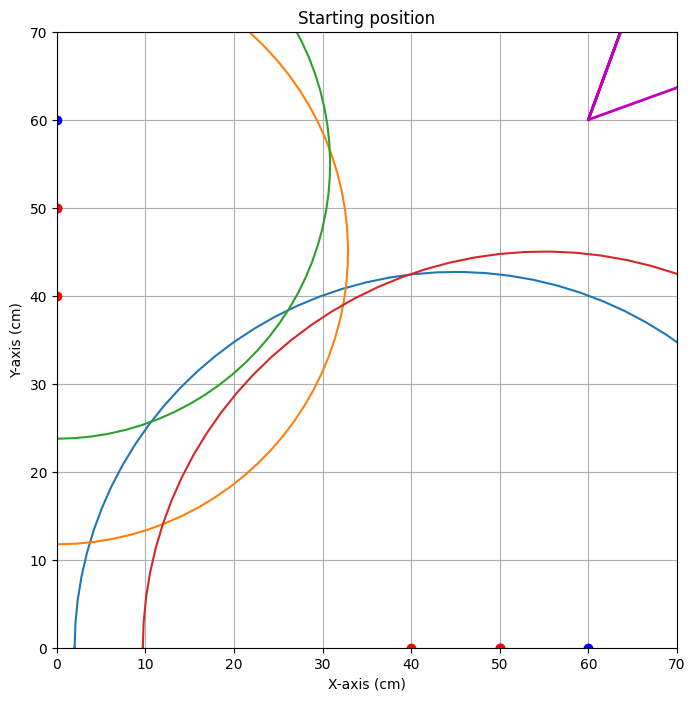


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.173


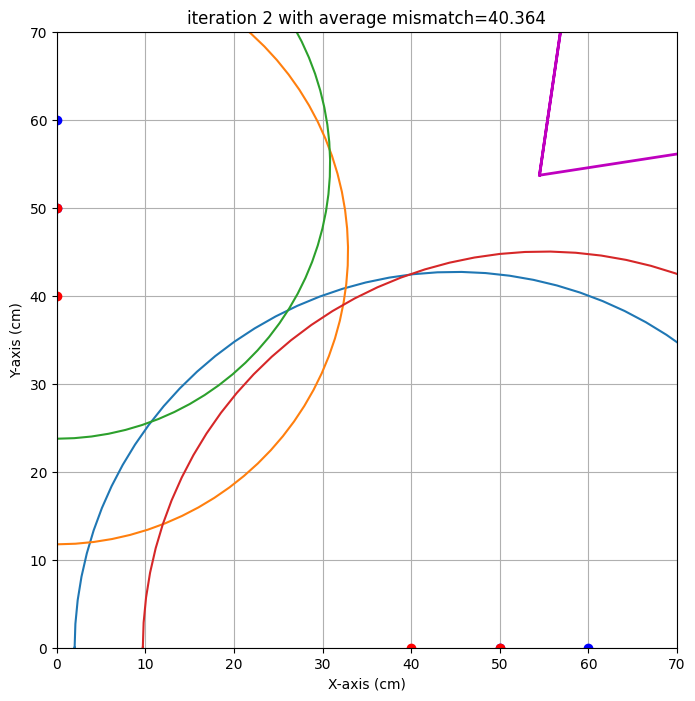

end iteration 2 with average mismatch=40.364


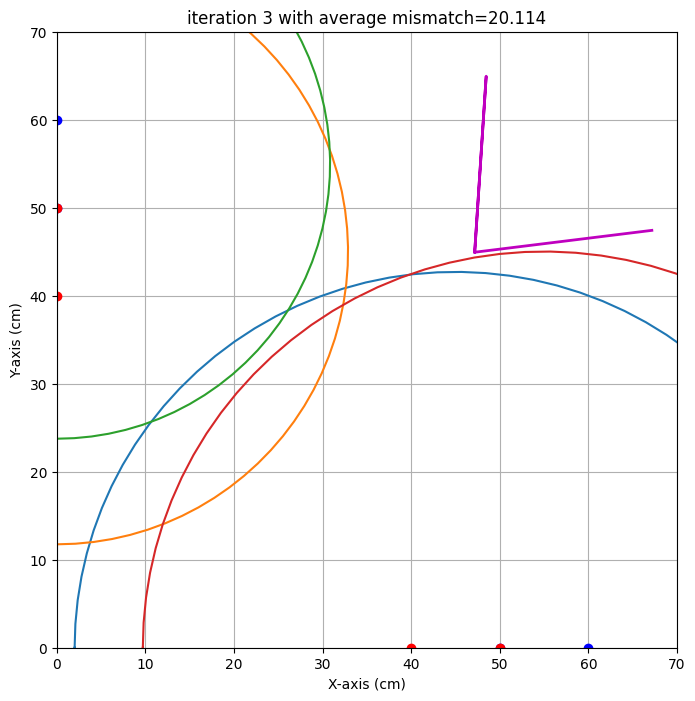

end iteration 3 with average mismatch=20.114


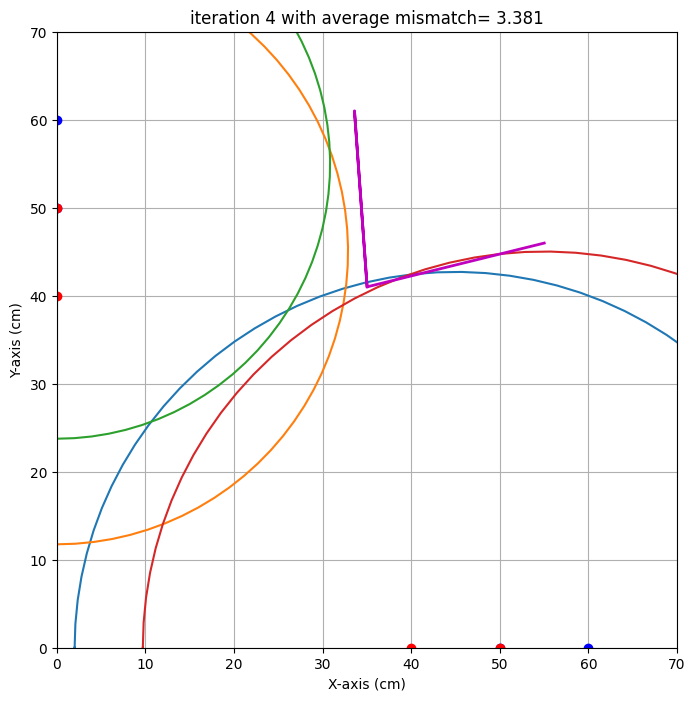

end iteration 4 with average mismatch= 3.381


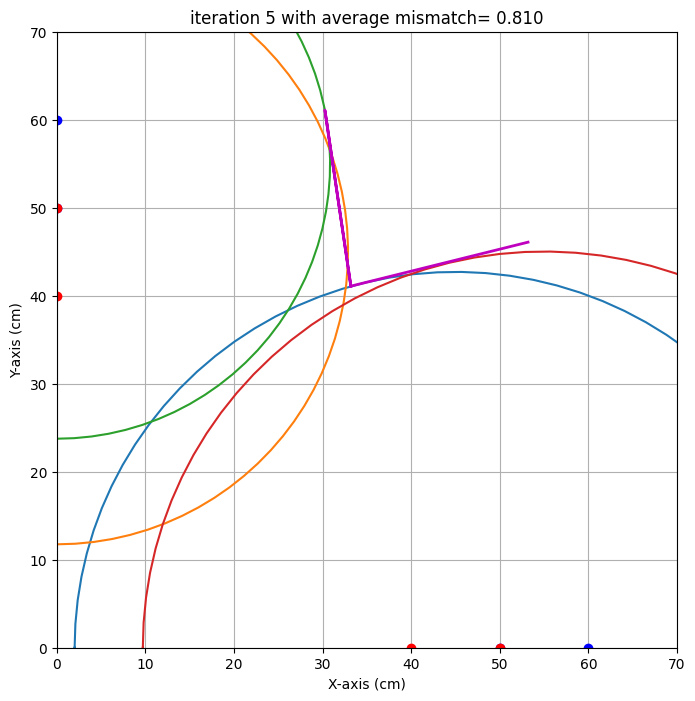

end iteration 5 with average mismatch= 0.810


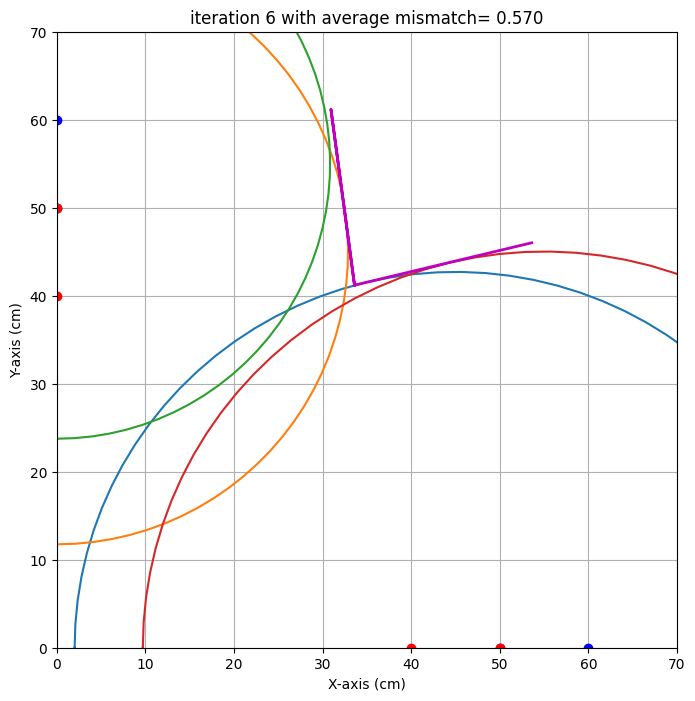

end iteration 6 with average mismatch= 0.570
end iteration 7 with average mismatch= 0.569


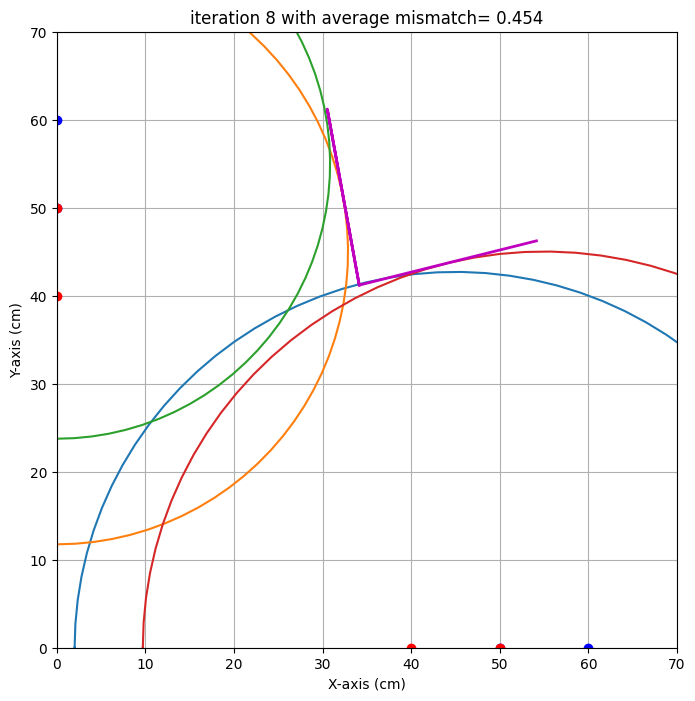

end iteration 8 with average mismatch= 0.454
end iteration 9 with average mismatch= 0.452
end iteration 10 with average mismatch= 0.452
end iteration 11 with average mismatch= 0.445
end iteration 12 with average mismatch= 0.433
end iteration 13 with average mismatch= 0.432


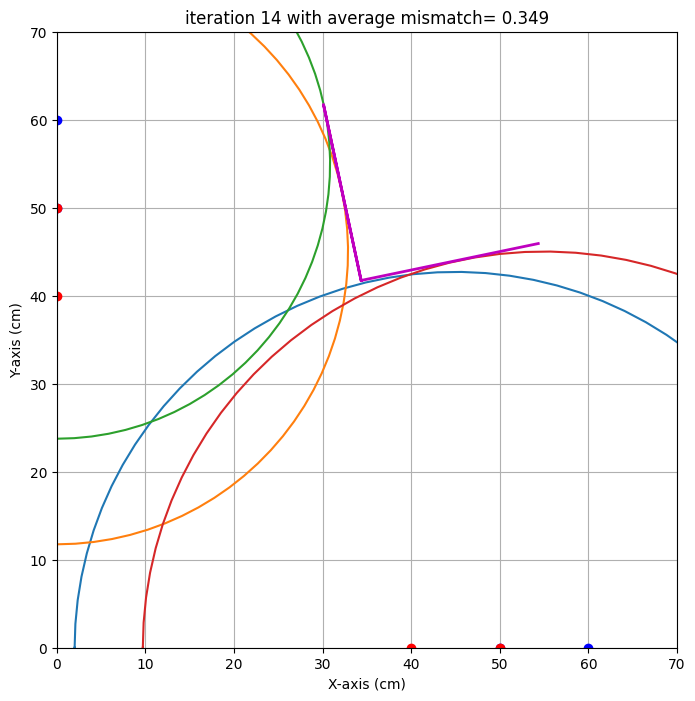

end iteration 14 with average mismatch= 0.349
end iteration 15 with average mismatch= 0.348
end iteration 16 with average mismatch= 0.348
end iteration 17 with average mismatch= 0.348
end iteration 18 with average mismatch= 0.348
end iteration 19 with average mismatch= 0.348
end iteration 20 with average mismatch= 0.348
end iteration 21 with average mismatch= 0.348
end iteration 22 with average mismatch= 0.348
end iteration 23 with average mismatch= 0.348
end iteration 24 with average mismatch= 0.348
end iteration 25 with average mismatch= 0.348
end iteration 26 with average mismatch= 0.348
end iteration 27 with average mismatch= 0.348
end iteration 28 with average mismatch= 0.348
end iteration 29 with average mismatch= 0.348
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.348
###############################################################################
end of iteration  30
Best alp

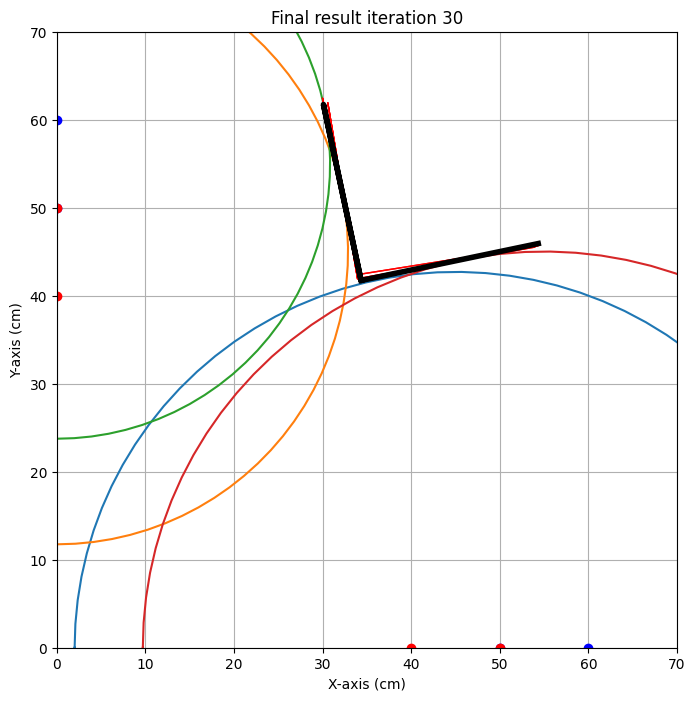

{'alpha': np.float64(11.843918219536095), 'alpha_eps': np.float64(2.7302416197458257), 'beta': np.float64(-11.997306707565393), 'beta_eps': np.float64(2.4543718492694424), 'x0': np.float64(34.34325037540098), 'x0_eps': np.float64(0.400849264715724), 'y0': np.float64(41.73155763770076), 'y0_eps': np.float64(0.7186654702618895)}
test locatie 
x0 target is : 34.2. Gevonden waarde: 34.3 cm met een standaardafwijking van 0.4 cm 
y0 target is : 40.0. Gevonden waarde: 41.7 cm met een standaardafwijking van 0.7 cm 
alpha target is : 14.0. Gevonden waarde: 11.8 graden met een standaardafwijking van 2.7 graad 
beta target is : -11.0. Gevonden waarde: -12.0 graden met een standaardafwijking van 2.5 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 34.2,
                    'y0': 40,
                    'alpha' : 14, 
                    'beta' : -11 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0,86],
                    [0,40,0,50, 66.5],
                    [0,50,0,60,62.5],
                    #[0,60,0,70, 160],
                    [50,0,60,0, 90.6],
                    # [30,0,40,0, 160]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Leerdoel 1: Inzien dat het maken van een algoritme een ontwerpproces.

Figuur: ![Alt](algoritme_meike.jpeg "0e iteratie")
bij de eerste schetsen van algoritmes waren er nog een paar problemen, zoals oneindig doorlopende schemas en als het begon met een geldige keuze op de x as, het algoritme niet verder ging naar de y-as.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg "1e iteratie")

ten opzichte van het eerst algoritme is er hier toegevoegd dat er in stapjes van 10cm wordt gewerkt. Ook zijn er stops toegevoegd en paden uitgebreid die eerst vroegtijdig eindigden. 

Figuur: ![Alt](uiteindelijke_algoritme.jpeg "Uiteindelijke algoritme")
We zagen dat een ellips soms de punt raakt, waardoor de meting ongeldig moest worden. Dus dit hebben we aan het algoritme toegevoegd.

Leerdoel 2: De ontwerpcyclus optimaal inrichten op de randvoorwaarden van de ontwerpopdracht.

Figuur: ![Alt](algoritme_meike.jpeg "0e iteratie")
bij de eerste schetsen van algoritmes waren er nog een paar problemen, zoals oneindig doorlopende schemas en als het begon met een geldige keuze op de x as, het algoritme niet verder ging naar de y-as.

Figuur: ![Alt](algoritme_eerste_iteratie.jpeg "1e iteratie")

ten opzichte van het eerst algoritme is er hier toegevoegd dat er in stapjes van 10cm wordt gewerkt. Ook zijn er stops toegevoegd en paden uitgebreid die eerst vroegtijdig eindigden. 

Figuur: ![Alt](uiteindelijke_algoritme.jpeg "Uiteindelijke algoritme")
We zagen dat een ellips soms de punt raakt, waardoor de meting ongeldig moest worden. Dus dit hebben we aan het algoritme toegevoegd.


Onderstaande code is ook om te laten zien dat we leerdoel 2 gehaald hebben.

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  86.0
1   0  40   0  50  66.5
2   0  50   0  60  62.5
3  50   0  60   0  90.6


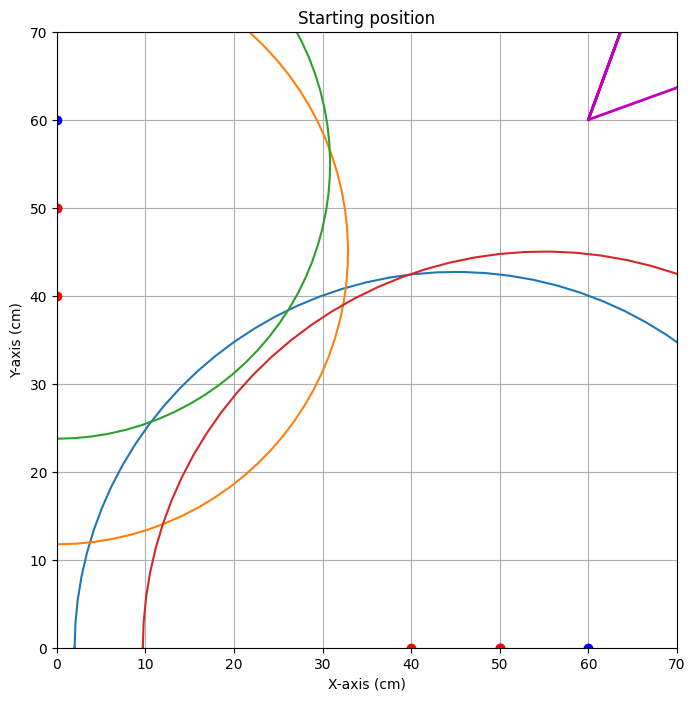


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.173


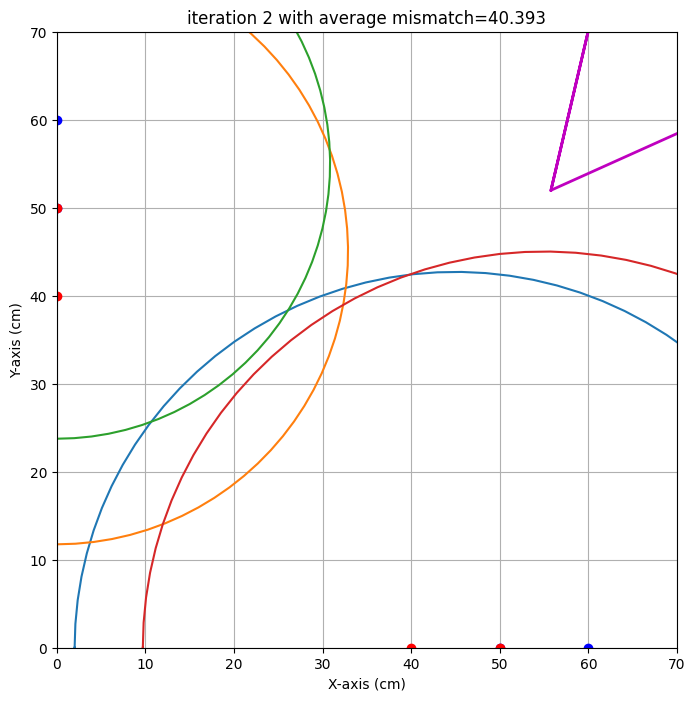

end iteration 2 with average mismatch=40.393


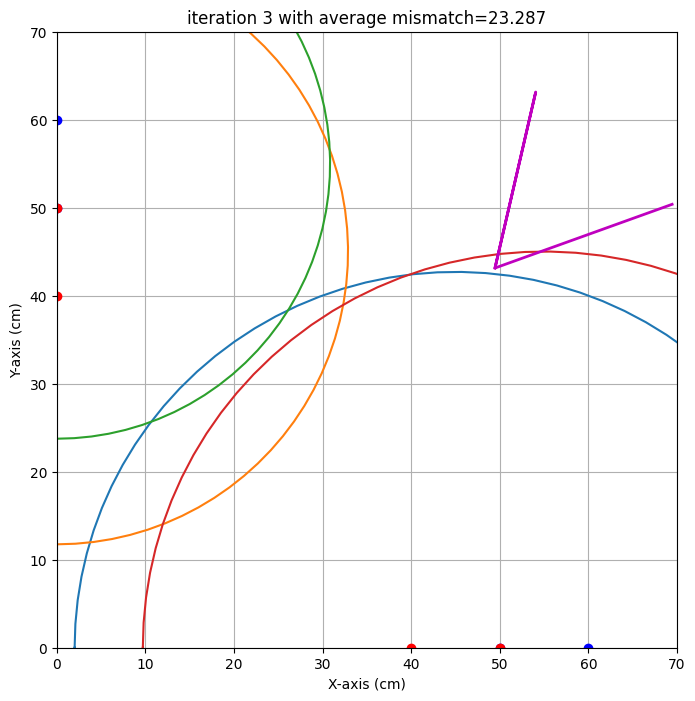

end iteration 3 with average mismatch=23.287


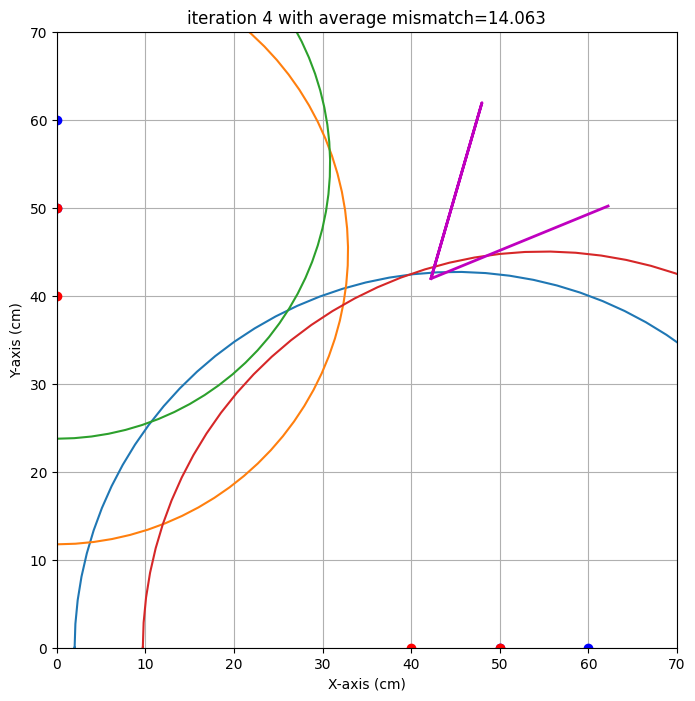

end iteration 4 with average mismatch=14.063


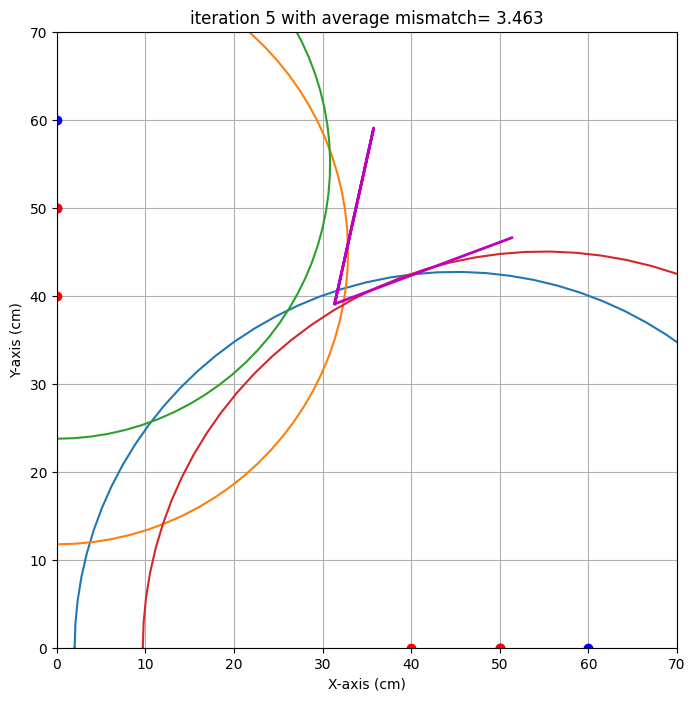

end iteration 5 with average mismatch= 3.463


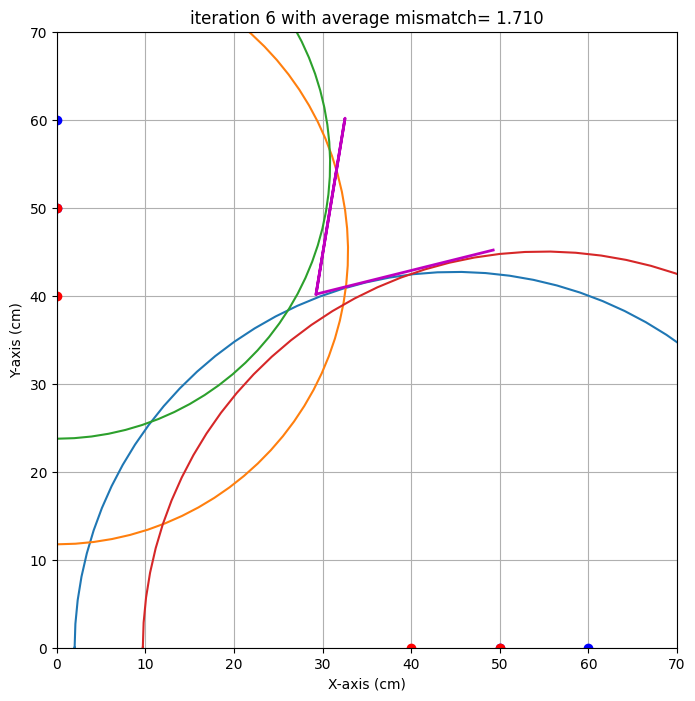

end iteration 6 with average mismatch= 1.710
end iteration 7 with average mismatch= 1.596
end iteration 8 with average mismatch= 1.485
end iteration 9 with average mismatch= 1.422
end iteration 10 with average mismatch= 1.286
end iteration 11 with average mismatch= 1.286
end iteration 12 with average mismatch= 1.286
end iteration 13 with average mismatch= 1.286
end iteration 14 with average mismatch= 1.286


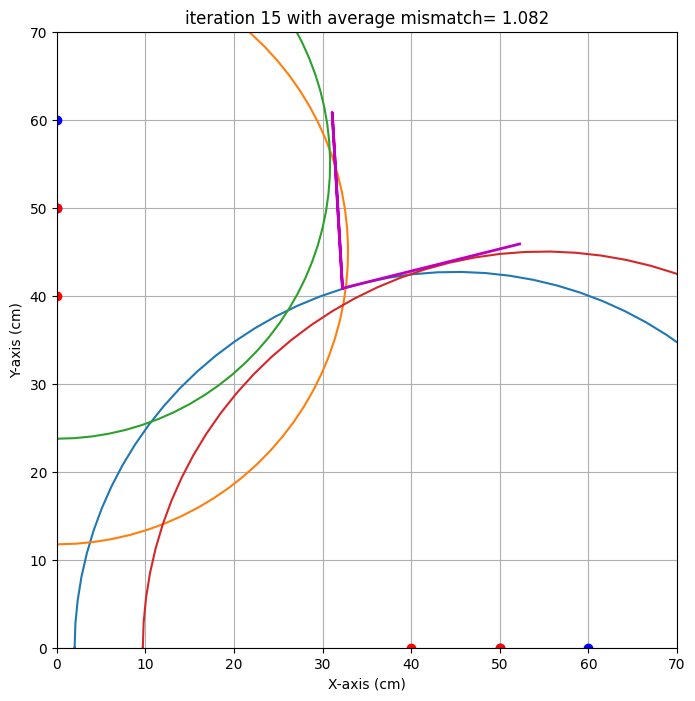

end iteration 15 with average mismatch= 1.082


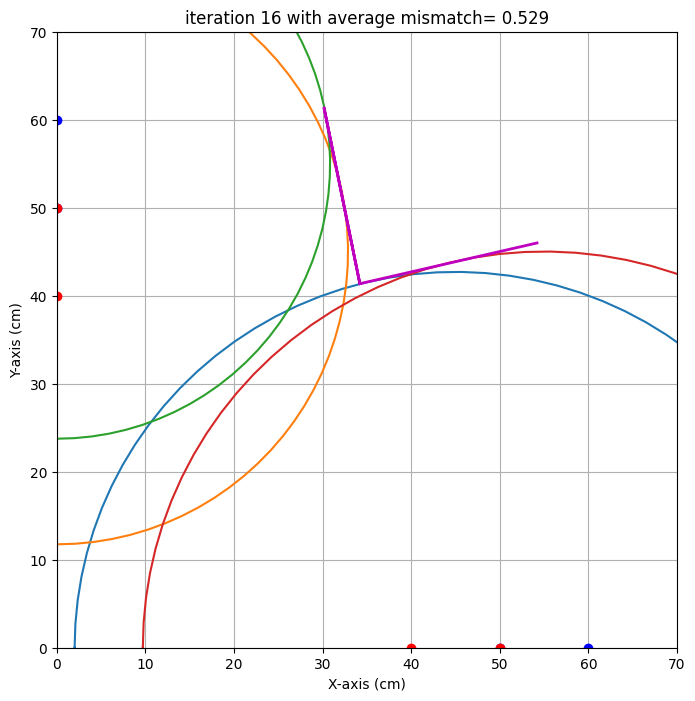

end iteration 16 with average mismatch= 0.529


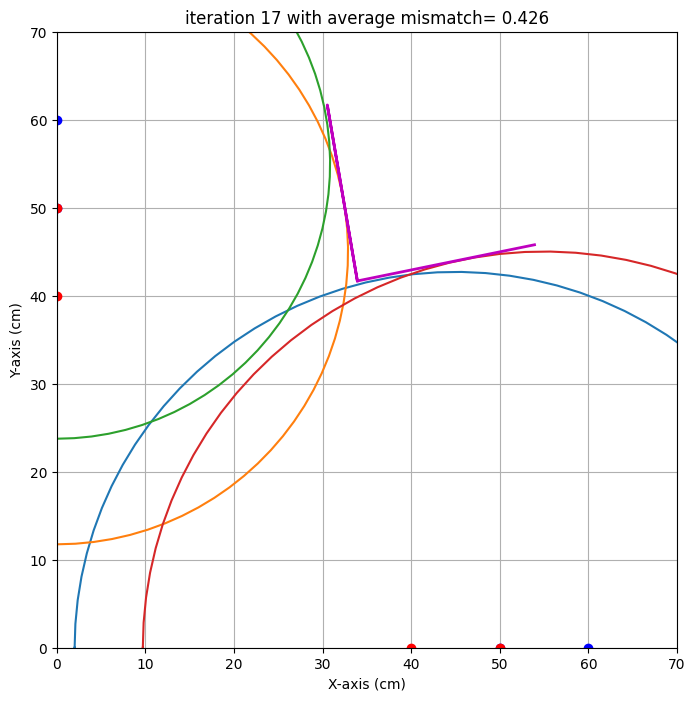

end iteration 17 with average mismatch= 0.426
end iteration 18 with average mismatch= 0.410
end iteration 19 with average mismatch= 0.405


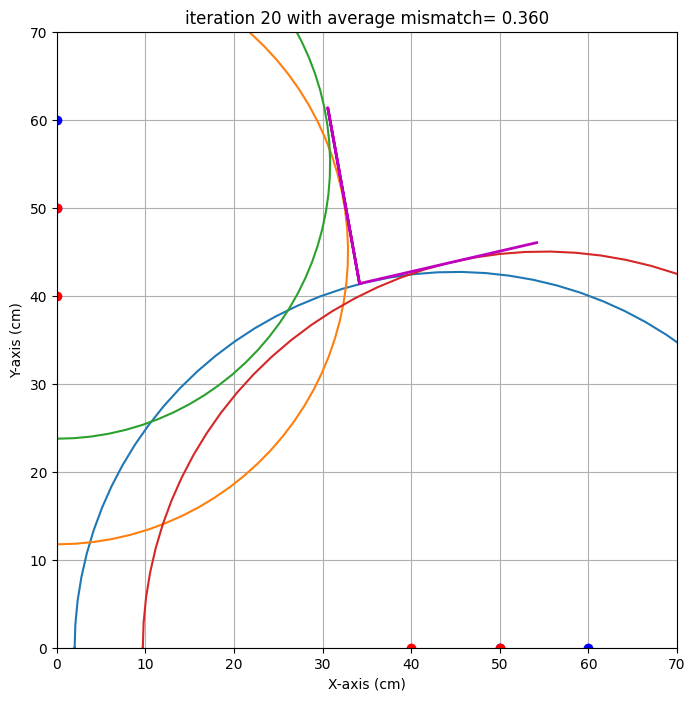

end iteration 20 with average mismatch= 0.360
end iteration 21 with average mismatch= 0.343
end iteration 22 with average mismatch= 0.324
end iteration 23 with average mismatch= 0.322
end iteration 24 with average mismatch= 0.321
end iteration 25 with average mismatch= 0.321
end iteration 26 with average mismatch= 0.302
end iteration 27 with average mismatch= 0.302
end iteration 28 with average mismatch= 0.302
end iteration 29 with average mismatch= 0.302
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.302
###############################################################################
end of iteration  30
Best alpha=  13.05 with uncertainty=   0.42
Best beta = -11.93 with uncertainty=   6.14
Best x0   =  34.37 with uncertainty=   0.91
Best y0   =  41.40 with uncertainty=   0.18
###############################################################################


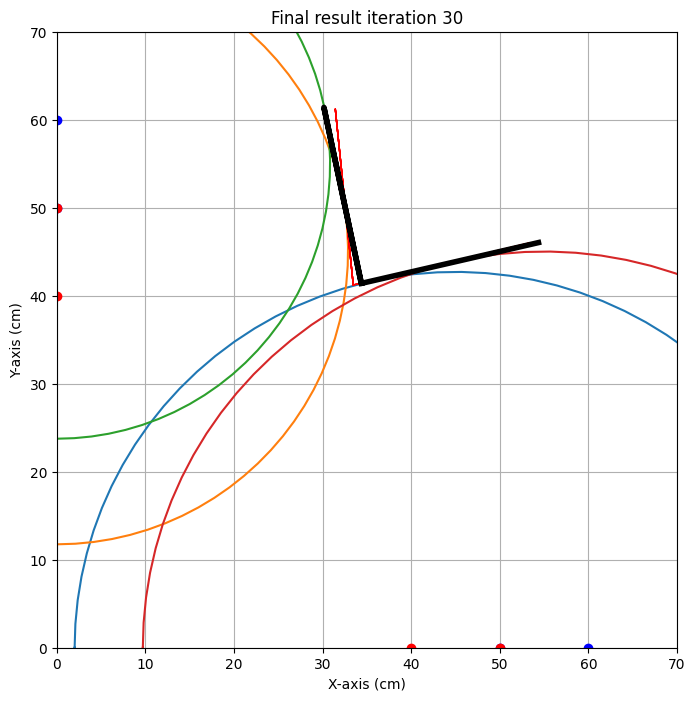

{'alpha': np.float64(13.050452899838357), 'alpha_eps': np.float64(0.41880277958885515), 'beta': np.float64(-11.931940647840769), 'beta_eps': np.float64(6.143046462982907), 'x0': np.float64(34.371428853530674), 'x0_eps': np.float64(0.9127588250609691), 'y0': np.float64(41.401740123001936), 'y0_eps': np.float64(0.17859210652500224)}
test locatie 
x0 target is : 34.2. Gevonden waarde: 34.4 cm met een standaardafwijking van 0.9 cm 
y0 target is : 40.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 0.2 cm 
alpha target is : 14.0. Gevonden waarde: 13.1 graden met een standaardafwijking van 0.4 graad 
beta target is : -11.0. Gevonden waarde: -11.9 graden met een standaardafwijking van 6.1 graad 



In [14]:
# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 34.2,
                    'y0': 40,
                    'alpha' : 14, 
                    'beta' : -11 
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0,86],
                    [0,40,0,50, 66.5],
                    [0,50,0,60,62.5],
                    #[0,60,0,70, 160],
                    [50,0,60,0, 90.6],
                    # [30,0,40,0, 160]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))